# NicheSphere tutorial (PIC-seq)

NicheSphere is an sc-verse compatible Python library which allows the user to find differentially colocalised cellular niches based on cell type pairs co-localization probabilities in different conditions. Cell type pair co-localization probabilities are obtained from deconvoluted spatial transcriptomics / PIC-seq data (probaabilities of finding each cell type in each spot / multiplet) as the probabilities to find each cell type pair in the same spot/multiplet.

It also offeres the possibility to look at differentially communicating cellular niches based on Ligand-Receptor pairs expression data, such as results from CrossTalkeR [ref].

Moreover, NicheSphere combines co-localization and communication networks via communication-weighted co-localization based distances to find differentially interacting niches.


## Libraries and functions

In [1]:
import pandas as pd
import numpy as np
import scipy
import scipy.io
import scipy.spatial.distance
import seaborn as sns
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import warnings
import scanpy as sc
import anndata as ad
import os
import random
import time
from collections import Counter
from joblib import Parallel, delayed
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
import nichesphere

In [2]:
import pycrosstalker

In [3]:
from community_layout.layout_class import CommunityLayout

COMMUNITY LAYOUT: Datashader not found, edge bundling not available


## PIC-seq data at first glance

In this tutorial, we apply NicheSphere to the bone marrow fibrosis PIC-seq data in [ref] to investigate bone marrow fibrosis-related cell microenvironment.

As a previous step, we used annotated scRNA-seq data to interrogate which cell type pairs can be found in the physically interacting cells data. This is known as cell type deconvolution and can be done with diverse methods. In this case, we used BayesPrism [ref], but any method returning a table of cell type proportions per multiplet/spot as the following one can be used.

Cell type proportions in doublets

In [4]:
CTprops=pd.read_csv('../res_data/revision/deconvolution/PICseq_doublets_CTprops_BP_annotation_noMSCs_Xist_newNames.csv', index_col=0)
CTprops.head()

,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells
IS3_AAACCCAAGAGTCAGC-1,0.022321,0.009692,0.002134,0.019810,0.027176,0.005223,0.005350,0.006909,0.859264,0.013108,0.004198,0.002142,0.004581,0.008093,0.008558,0.001440
IS3_AAACCCAAGGGCTGAT-1,0.009302,0.013937,0.003087,0.008581,0.013993,0.868811,0.012865,0.014621,0.009612,0.008361,0.005726,0.003589,0.009012,0.008289,0.008231,0.001982
IS3_AAACCCACACGCCAGT-1,0.675809,0.260256,0.001310,0.006162,0.004601,0.005598,0.004135,0.005520,0.009202,0.010234,0.002177,0.001419,0.002356,0.006113,0.004108,0.001000
IS3_AAACCCACACTACCGG-1,0.002942,0.003383,0.001131,0.850736,0.101740,0.002235,0.004787,0.002345,0.007967,0.005849,0.001834,0.001331,0.002962,0.003802,0.006055,0.000903
IS3_AAACCCACAGATCCTA-1,0.030429,0.079342,0.005465,0.013012,0.047528,0.643361,0.025168,0.012989,0.035907,0.018483,0.043229,0.005768,0.010787,0.014002,0.010533,0.003997


The probabilities of the different cell types should sum up to 1 for each spot/multiplet.

In [5]:
CTprops.sum(axis=1).head()

IS3_AAACCCAAGAGTCAGC-1    1.0
IS3_AAACCCAAGGGCTGAT-1    1.0
IS3_AAACCCACACGCCAGT-1    1.0
IS3_AAACCCACACTACCGG-1    1.0
IS3_AAACCCACAGATCCTA-1    1.0
dtype: float64

We will need as well the scRNA-seq data and the multiplets / spots data

scRNA-seq data:

In [6]:
adata_singlets=sc.read('../data/PICseq/final_data/adata_singlets_final.h5ad')

Multiplets sequencing data:

In [7]:
adata_doublets=sc.read('../data/PICseq/final_data/adata_doublets_final.h5ad')

## **Differential co-localization analysis**

We will compute co-localization probabilities from deconvolution results (cell type probabilities per spot) with the function getColocProbs to get cell type pairs co-localization probabilities

Here we will get concatenated co-localization matrices of cell type x cell type. The last column of the matrix indicates the corresponding sample

In [8]:
CTcolocalizationP= nichesphere.coloc.getColocProbs(CTprobs=CTprops, spotSamples=adata_doublets.obs.stage)
CTcolocalizationP.head()

,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells,sample
DC,0.043204,0.011930,0.000577,0.007006,0.002704,0.004632,0.001131,0.001506,0.005417,0.004213,0.001673,0.000537,0.000650,0.001424,0.001665,0.000200,TPO
InfiltMac,0.011930,0.090976,0.001273,0.005785,0.005563,0.021474,0.002519,0.003258,0.005380,0.003517,0.004492,0.001227,0.001781,0.002080,0.003197,0.000545,TPO
Fibro,0.000577,0.001273,0.016769,0.000746,0.000636,0.001370,0.000348,0.000389,0.000755,0.000503,0.000454,0.001178,0.000605,0.000291,0.000426,0.000077,TPO
MonoPro,0.007006,0.005785,0.000746,0.067752,0.007023,0.004591,0.002202,0.001787,0.009067,0.007756,0.001404,0.000822,0.000940,0.001665,0.001426,0.000261,TPO
Neut2,0.002704,0.005563,0.000636,0.007023,0.034074,0.005379,0.001408,0.001432,0.012879,0.001878,0.001241,0.000619,0.000780,0.001300,0.001172,0.000269,TPO


Same cell type interactions can be excluded later on, so we'll have a list of same cell type interaction pairs in order to subset the co-localization table we'll generate in the next step.

In [9]:
oneCTints=CTcolocalizationP.columns[range(len(CTcolocalizationP.columns)-1)]+'-'+CTcolocalizationP.columns[range(len(CTcolocalizationP.columns)-1)]

Then we will reshape the co-localization data into a matrix of cell type pairs x samples. Set the parameter 'complete' to 1 if co-localization repeated values (ct1_x_ct2 and ct2_x_ct1) are included in your data. If co-localization repeated values are not there, you should set 'complete' to 0.

In [10]:
colocPerSample=nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
colocPerSample

,DC-DC,DC-InfiltMac,DC-Fibro,DC-MonoPro,DC-Neut2,DC-Ly6ClowMac,DC-Baso,DC-TCells,DC-Neut1,DC-MK,...,BCells-Baso,BCells-TCells,BCells-Neut1,BCells-MK,BCells-ResMac,BCells-OsteoCAR,BCells-EC,BCells-Ery,BCells-Spp1+Mac,BCells-BCells
TPO,0.043204,0.011930,0.000577,0.007006,0.002704,0.004632,0.001131,0.001506,0.005417,0.004213,...,0.000112,0.000134,0.000347,0.000144,0.000150,0.000077,0.000050,0.00007,0.000078,0.000504
EV,0.018899,0.003145,0.002420,0.009168,0.004171,0.001827,0.001256,0.003089,0.006253,0.005446,...,0.000338,0.000741,0.001673,0.001140,0.000657,0.000472,0.000449,0.00168,0.001045,0.004976


Probabilities of all cell type pairs in each sample should sum up to 1:

In [11]:
colocPerSample.sum(axis=1)

TPO    1.0
EV     1.0
dtype: float64

In this case, we do not have multiple samples from our two different conditions, so we will test differential co-localization by calculating O/E ratios of co-localization probabilities of cell type pairs in randomly generated doublets from our singlets data. We will generate a background distribution per cell type pair (with default n = 1000) from here and compare the O/E ratios we get from our data to this background distributions. 

# Co-localization with one background distribution per cell type pair

First we will generate the background distribution from our singlets data. 

In [12]:
# Background distribution WITHOUT proportion correction
res = nichesphere.tl.get_PIC_BG_OEratios_DF(
    adata=adata_singlets[adata_singlets.obs.stage == 'TPO'],
    annot_col='annotation',
    target_pairs=colocPerSample.columns,
    nreps=1000,
    njobs=10,
)

41.3511004447937


In [13]:
df = res  # get_PIC_BG_OEratios_DF already returns the concatenated DataFrame

In [14]:
df.head()

,DC-DC,DC-InfiltMac,DC-Fibro,DC-MonoPro,DC-Neut2,DC-Ly6ClowMac,DC-Baso,DC-TCells,DC-Neut1,DC-MK,...,BCells-Baso,BCells-TCells,BCells-Neut1,BCells-MK,BCells-ResMac,BCells-OsteoCAR,BCells-EC,BCells-Ery,BCells-Spp1+Mac,BCells-BCells
OE_Ratio,0.802750,0.918187,1.240722,1.119305,0.919996,0.999588,1.007649,1.381042,1.063953,0.386580,...,1.906471e-10,3.842547e-10,1.735344e-10,6.095074e-10,1.393356e+00,1.586282e-09,6.377835e-10,2.291296e-09,8.248667e-09,6.512105e-09
OE_Ratio,1.411732,0.937723,1.033935,0.829114,0.674664,1.072138,0.967343,1.218567,0.990577,1.030879,...,1.906471e-10,3.842547e+00,1.735344e-10,6.095074e-10,1.393356e-10,1.586282e-09,6.377835e+00,2.291296e-09,8.248667e-09,6.512105e-09
OE_Ratio,0.830431,0.986563,0.620361,1.057121,1.165329,1.144689,1.007649,0.974853,0.990577,1.546319,...,3.812943e+00,3.842547e-10,1.735344e+00,6.095074e-10,1.393356e+00,1.586282e-09,6.377835e-10,2.291296e-09,8.248667e-09,6.512105e-09
OE_Ratio,1.190284,0.879115,1.240722,1.140032,1.011996,1.096322,0.927037,1.137329,0.990577,1.159739,...,1.906471e+00,3.842547e-10,1.735344e-10,6.095074e-10,1.393356e-10,1.586282e-09,6.377835e-10,2.291296e-09,8.248667e-09,6.512105e+01
OE_Ratio,0.996517,0.937723,0.620361,0.746203,1.042663,0.910914,1.370402,0.568664,1.174017,0.773159,...,1.906471e-10,3.842547e-10,1.735344e+00,6.095074e-10,2.786712e+00,1.586282e+01,6.377835e-10,2.291296e-09,8.248667e-09,6.512105e-09


Then, we will compute the expected probability of each cell type pair to occur in each condition by multiplying cell type proportions from the single cell data.

In [15]:
TPO_cell_list = list(adata_singlets[adata_singlets.obs.stage == 'TPO'].obs['annotation'])
TPO_cell_series = pd.Series(TPO_cell_list)

In [16]:
scCTpairsProbs_TPO = nichesphere.tl.getExpectedColocProbsFromSCs(
    cell_types=CTprops.columns,
    annot_series=TPO_cell_series,
)
scCTpairsProbs_TPO.head()

,count
DC-DC,0.005846
DC-InfiltMac,0.016548
DC-Fibro,0.001563
DC-MonoPro,0.007798
DC-Neut2,0.005271


Afterwards, we will calculate observed / expected ratios and log2 scale them with the function OvsE_coloc_test. We filter the same cell interactions as well. This function can also filter non significant values given a p-value (p). We will do this later to build the differential co-localization network

We can plot the log2(O/E) ratios in a heatmap and cluster the cells according to these scores.

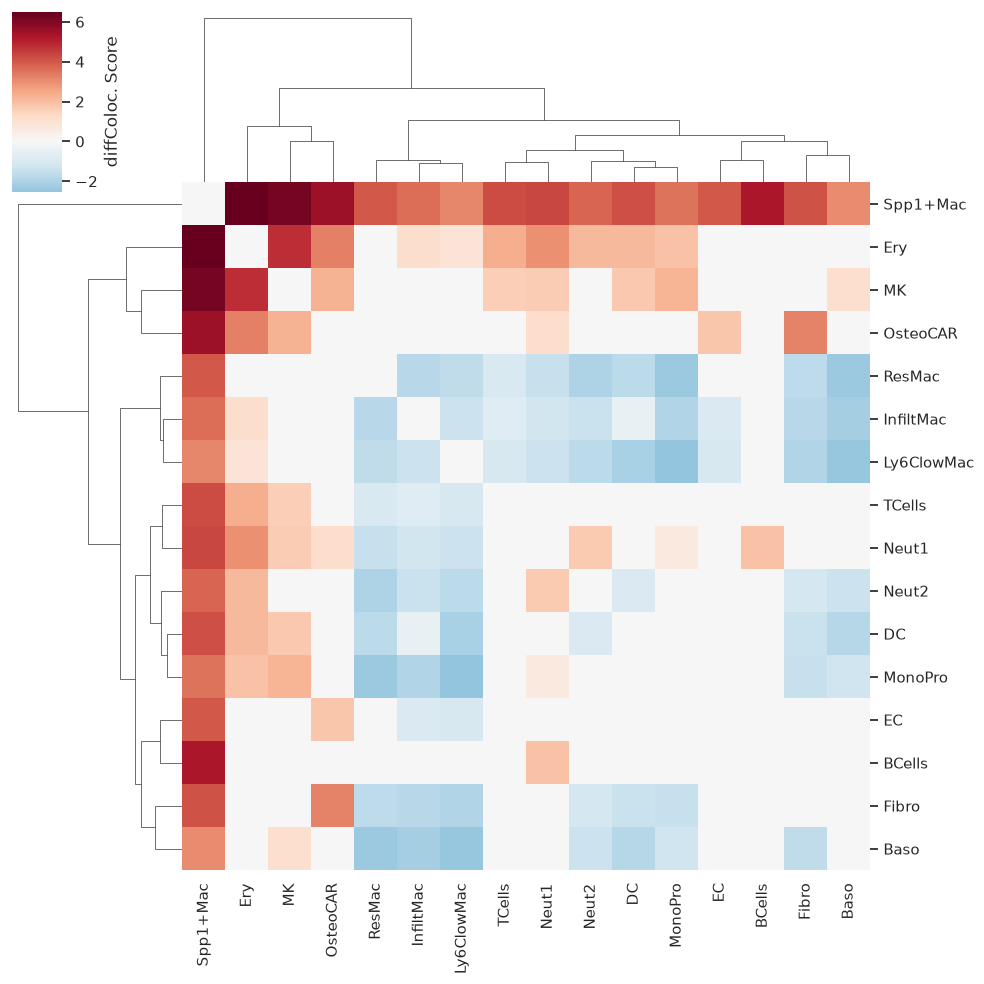

In [17]:
OvsE_TPO_HMdf,stats=nichesphere.coloc.OvsE_coloc_test_adjPval(observedColocProbs=colocPerSample.loc['TPO'], expectedColocProbs=scCTpairsProbs_TPO['count'], cell_types=CTprops.columns, 
                              testDistribution_df=df, oneCTinteractions=oneCTints, p=0.1)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

The OvsE_coloc_test function returns the statistics data as well:

In [18]:
stats.head()

,statistic,pvalue,adjusted_pvalue
DC-DC,0.000000,0.000,0.000000
DC-InfiltMac,-0.472072,0.002,0.004491
DC-Fibro,-1.437430,0.016,0.030341
DC-MonoPro,0.000000,0.456,0.535486
DC-Neut2,-0.963086,0.000,0.000000


**Differential co-localization network**

To build the differential co-localization network, we will get an adjacency matrix (adj) based on the euclidean distances among the distributions of significant differential co-localization scores for the different cell types

In [19]:
HMdist=pd.DataFrame(scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(OvsE_TPO_HMdf)), 
                    columns=OvsE_TPO_HMdf.columns, index=OvsE_TPO_HMdf.index)

HMsimm=1-HMdist/HMdist.max().max()
##Cell pairs with not significant differential co-localization get 0
HMsimm[OvsE_TPO_HMdf==0]=0

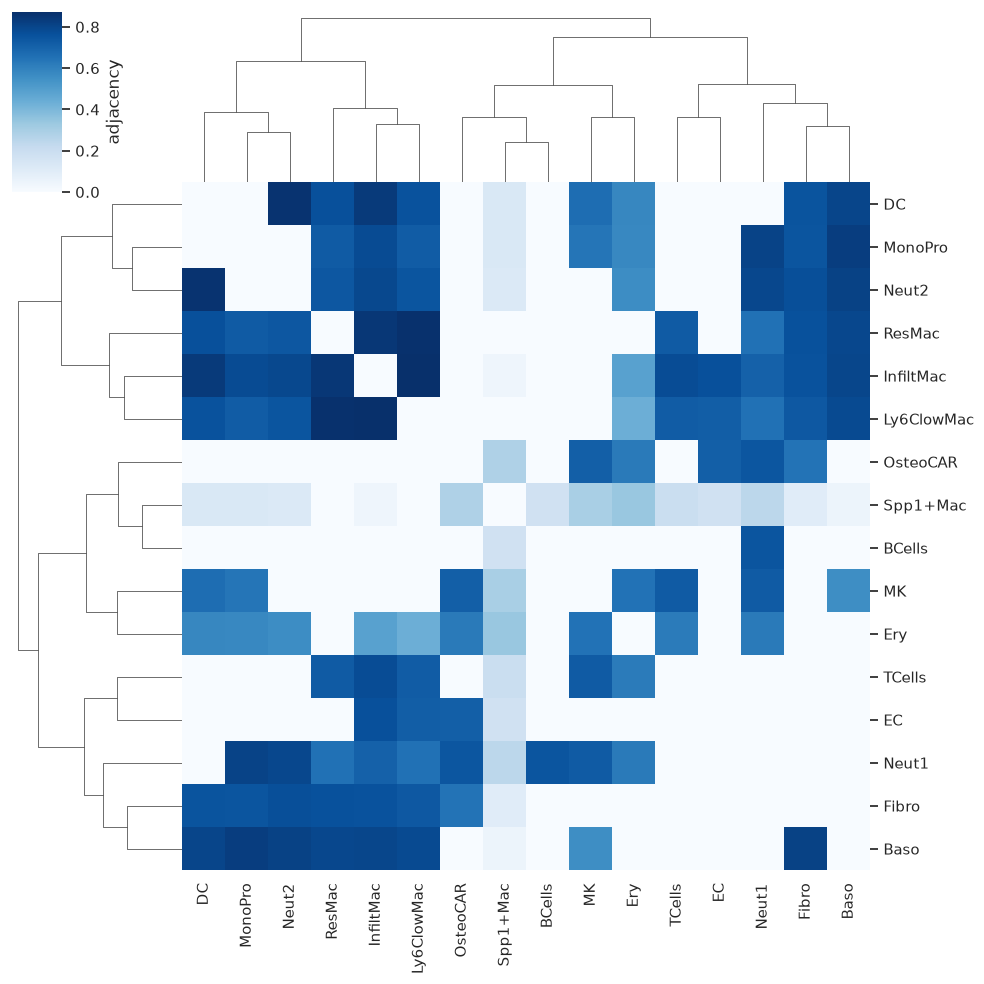

In [20]:
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})

We will assign each niche a color to plot them later on (we haven't clustered yet, so we use the same color for all nodes)

In [21]:
niches_dict={'1_': list(OvsE_TPO_HMdf.index)}
clist=['#4daf4a']

Then the network is built just taking into account the differentially co-localized cell type pairs. The cell groups dictionary can be used here to visualize different cell groups in different colors.

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/sit

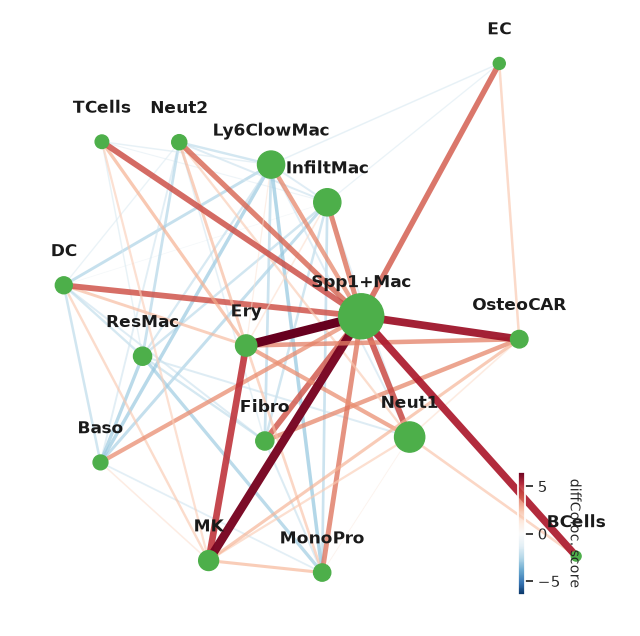

In [22]:
plt.rcParams['axes.facecolor'] = "None"
gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, adj=HMsimm,cell_group=niches_dict, clist=clist, nodeSize='betweeness', layout='neato', thr=0)

In [23]:
## Unsigned network
gCol2=nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

Now we'll do community detection using Louvain and make a communities dict

In [24]:
## Network clustering / clustering alternative
d=nx.algorithms.community.louvain_communities(gCol2,resolution=1.2, seed=1, weight='weight')
niches_dict=dict(enumerate([list(x) for x in d]))
niches_dict

{0: ['Baso', 'ResMac', 'Fibro', 'Neut2', 'DC'],
 1: ['TCells', 'MK', 'Ery', 'Spp1+Mac', 'OsteoCAR'],
 2: ['InfiltMac', 'EC', 'Ly6ClowMac'],
 3: ['BCells', 'Neut1', 'MonoPro']}

In [25]:
niche_names=['1_Neut_ResMac_Baso_DC', '2_FibCore', '3_InfiltMacs_EC', '4_BCells_MonoPro_Neut']
niches_dict=dict(zip(niche_names,list(niches_dict.values()))) 


In [26]:
#Niches colors
clist=['#FDBCB4', '#4C9A2A', '#C8A2C8', '#4A6984']

niche_cols=pd.Series(clist, index=list(niches_dict.keys()))
niches_df=nichesphere.tl.cells_niche_colors(CTs=CTprops.columns, niche_colors=niche_cols, niche_dict=niches_dict)

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/tl.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  niche_df['color']=niche_colors[0]


We will use the community-layout library function **CommunityLayout** to show the communities in a layout suited for this. This function is compatible with networkx (Hagberg et. al., 2008) community detection functions, which will be used internally as indicated by the parameters **community_algorithm** and **community_kwargs**

In [27]:
## Calculate community layout
cl=CommunityLayout(gCol2,
        community_compression = 0.3,
        layout_algorithm = nx.spring_layout,
        layout_kwargs = {"k":75, "iterations":1000},
        community_algorithm = nx.algorithms.community.louvain_communities,
        community_kwargs = {"resolution":1.2,  'seed':1, 'weight':'weight'})

Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 484.68it/s]


/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/sit

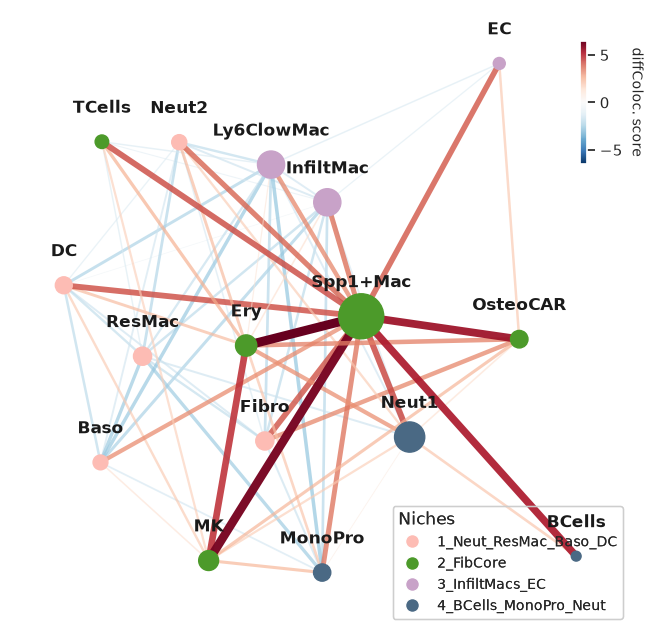

In [28]:
plt.rcParams['axes.facecolor'] = "None"

gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, adj=HMsimm,cell_group=niches_dict, clist=clist, 
                               nodeSize='betweeness', layout='neato', lab_spacing=9, thr=0, legend_ax=[0.8, 0.75, 0.15, 0.2])
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]

plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='lower right', fontsize=10, title='Niches', alignment='left'))


/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/sit

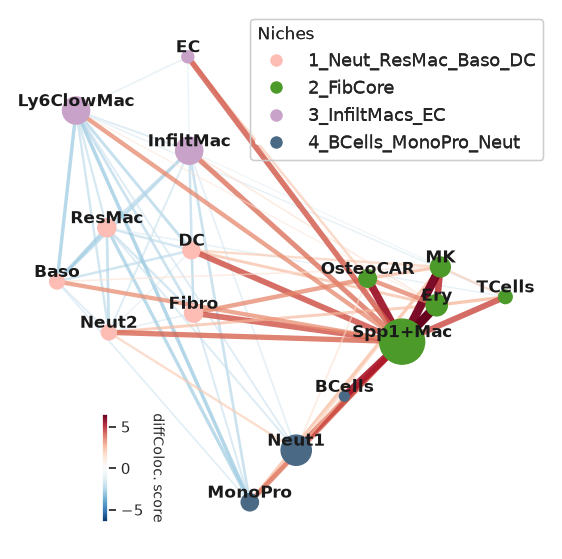

In [29]:
#pos=cl.full_positions
pos = np.load('../res_data/revision/node_positions/diffColocNW_BGdist_per_CTpair_node_pos.npy',allow_pickle='TRUE').item()
gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, 
                               adj=HMsimm,
                               cell_group=niches_dict, 
                               clist=clist, 
                               nodeSize='betweeness', 
                               layout=None,                         #layout needs to be set to None if we provide node positions
                               lab_spacing=0.05, 
                               thr=0, 
                               pos=pos,                             #node positions (from the CommunityLayout function)
                               edge_scale=1,                        #edge width
                               legend_ax=[0.05, 0.05, 0.15, 0.2],
                               fsize=(7,7)
                              )    #legend position
#Legend
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, 
                             label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]
plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='upper right', fontsize=13, title='Niches', 
                                alignment='left'))
#plt.savefig('../figures/revision/diffColocNW_CL_BGdist_per_CTpair.pdf')

In [30]:
#pos=nx.drawing.nx_agraph.graphviz_layout(gCol2,prog='neato')
np.save('../res_data/revision/node_positions/diffColocNW_BGdist_per_CTpair_node_pos.npy', pos) 

We can then calculate some network statistics with the networkX package [ref] functions:

In [31]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()

,betweenness,pagerank,degree_positive,degree_negative
DC,-23.920073,-0.909995,0.200000,0.400000
InfiltMac,-29.546512,-2.147101,0.133333,0.666667
Fibro,-25.183107,-1.140092,0.133333,0.400000
MonoPro,-23.920073,-1.019137,0.266667,0.333333
Neut2,-23.920073,-0.972552,0.200000,0.400000


And visualize them

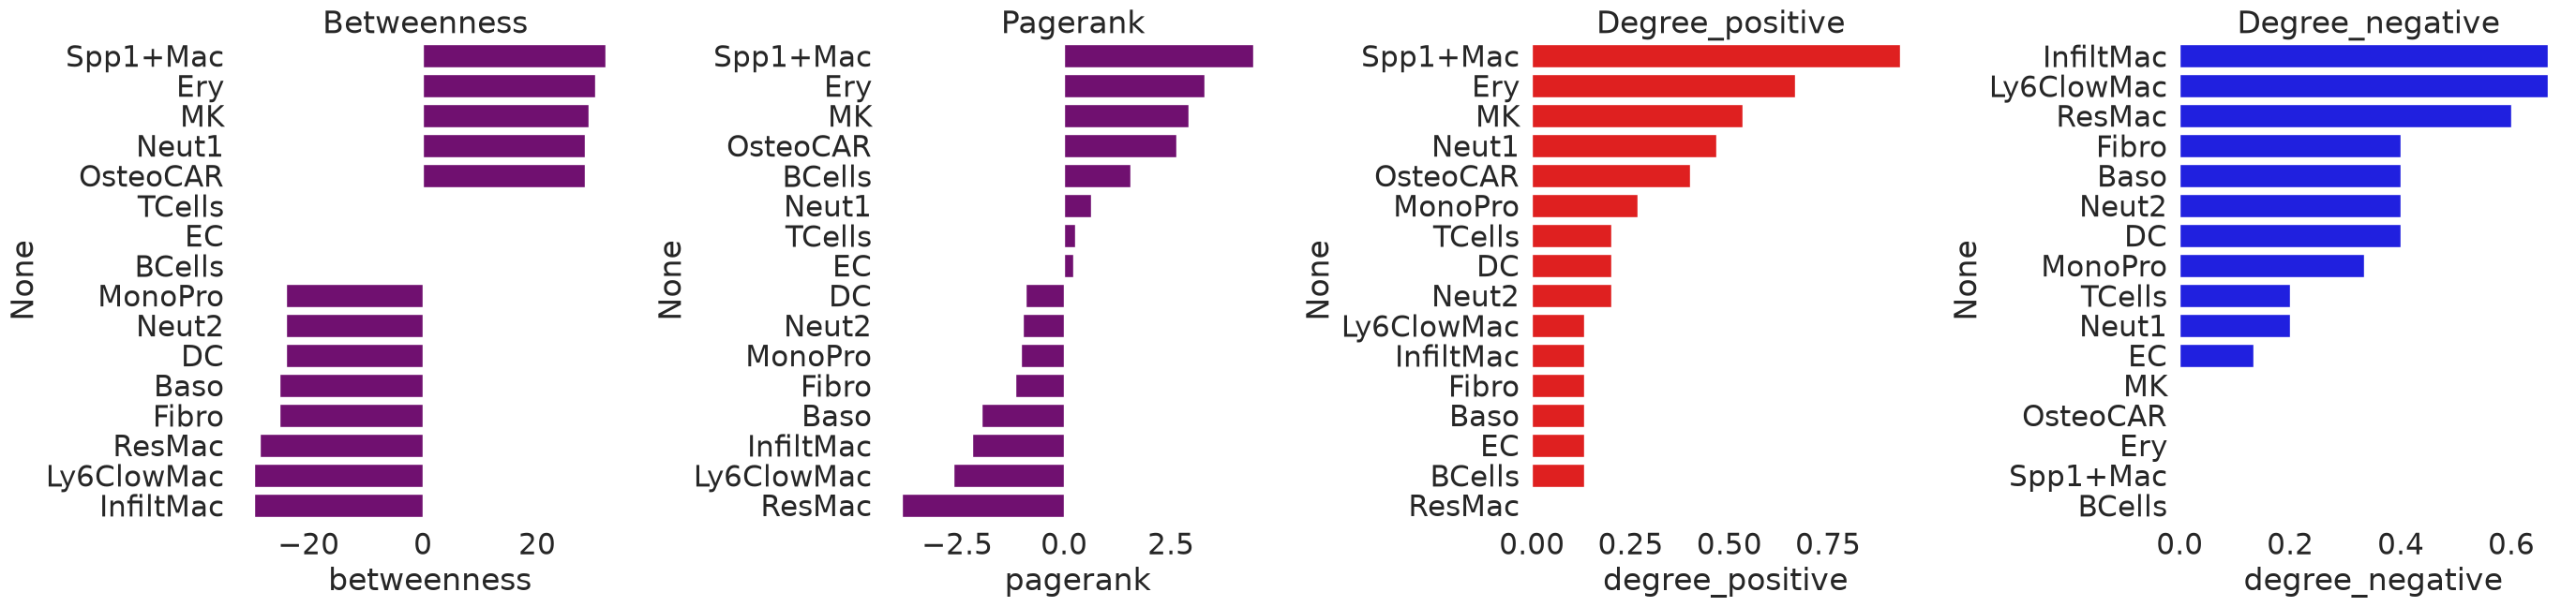

In [32]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats)
#plt.savefig('../figures/revision/diffColocNW_stats.pdf', bbox_inches='tight')

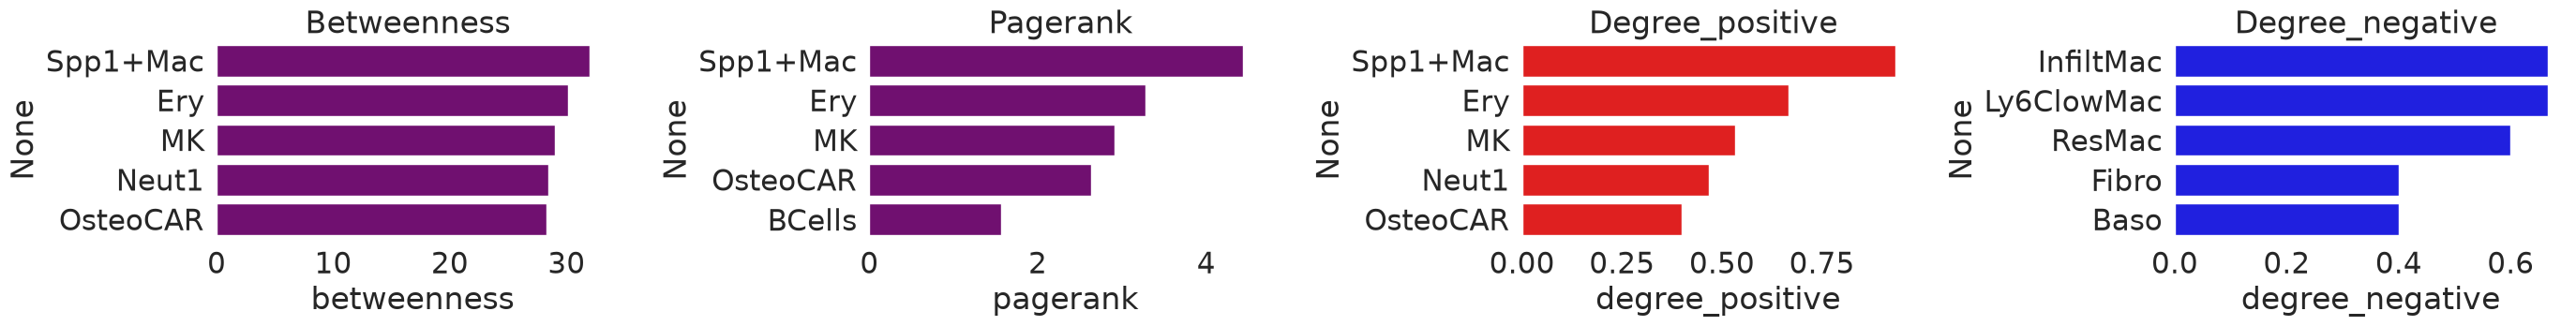

In [33]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats, top_n=5)
#plt.savefig('../figures/revision/diffColocNW_stats_top5.pdf', bbox_inches='tight')

# Pf4/Gli1 proportion adjustment

At the time of doing the gating, 10000 Pf4+ and 60000 Gli1+ cells were selected in order to increase the retrieval of CAR cells and Fibroblasts. We'll correct this bias by decreasing the proportion of Fibroblast or osteoCAR by a factor of 6

In [34]:
# Background distribution WITH Pf4/Gli1 proportion correction (downsampling Fibro and OsteoCAR by factor 6)
res = nichesphere.tl.get_PIC_BG_OEratios_DF(
    adata=adata_singlets[adata_singlets.obs.stage == 'TPO'],
    annot_col='annotation',
    target_pairs=colocPerSample.columns,
    nreps=1000,
    njobs=10,
    downsample_cells=True,
    cell_list_downsample=['Fibro', 'OsteoCAR'],
    downsampling_factor=6,
)
df = res  # get_PIC_BG_OEratios_DF already returns the concatenated DataFrame

26.276225805282593


In [35]:
# Background distribution WITH Pf4/Gli1 proportion correction (downsampling Fibro and OsteoCAR by factor 6)
res = nichesphere.tl.get_PIC_BG_OEratios_DF(
    adata=adata_singlets[adata_singlets.obs.stage == 'TPO'],
    annot_col='annotation',
    target_pairs=colocPerSample.columns,
    nreps=100,
    njobs=10,
    downsample_cells=True,
    cell_list_downsample=['Fibro', 'OsteoCAR'],
    downsampling_factor=6,
)
df_100 = res  # get_PIC_BG_OEratios_DF already returns the concatenated DataFrame

3.475801706314087


In [36]:
# Background distribution WITH Pf4/Gli1 proportion correction (downsampling Fibro and OsteoCAR by factor 6)
res = nichesphere.tl.get_PIC_BG_OEratios_DF(
    adata=adata_singlets[adata_singlets.obs.stage == 'TPO'],
    annot_col='annotation',
    target_pairs=colocPerSample.columns,
    nreps=500,
    njobs=10,
    downsample_cells=True,
    cell_list_downsample=['Fibro', 'OsteoCAR'],
    downsampling_factor=6,
)
df_500 = res  # get_PIC_BG_OEratios_DF already returns the concatenated DataFrame

12.657732725143433


In [37]:
TPO_cell_list = list(adata_singlets[adata_singlets.obs.stage == 'TPO'].obs['annotation'])
TPO_cell_list = nichesphere.tl.downsample_class(
    TPO_cell_list, target_class=['Fibro', 'OsteoCAR'], factor=6
)
TPO_cell_series = pd.Series(TPO_cell_list)

Then, we will compute the expected probability of each cell type pair to occur in each condition by multiplying cell type proportions from the single cell data. For this we will use the downsampled singlets data

In [38]:
scCTpairsProbs_TPO = nichesphere.tl.getExpectedColocProbsFromSCs(
    cell_types=CTprops.columns,
    annot_series=TPO_cell_series,
)
scCTpairsProbs_TPO.head()

,count
DC-DC,0.006115
DC-InfiltMac,0.017312
DC-Fibro,0.000272
DC-MonoPro,0.008158
DC-Neut2,0.005514


Afterwards, we will calculate observed / expected ratios and log2 scale them with the function OvsE_coloc_test. We filter the same cell interactions as well. This function can also filter non significant values given a p-value (p). We will do this later to build the differential co-localization network

We can plot the log2(O/E) ratios in a heatmap and cluster the cells according to these scores.

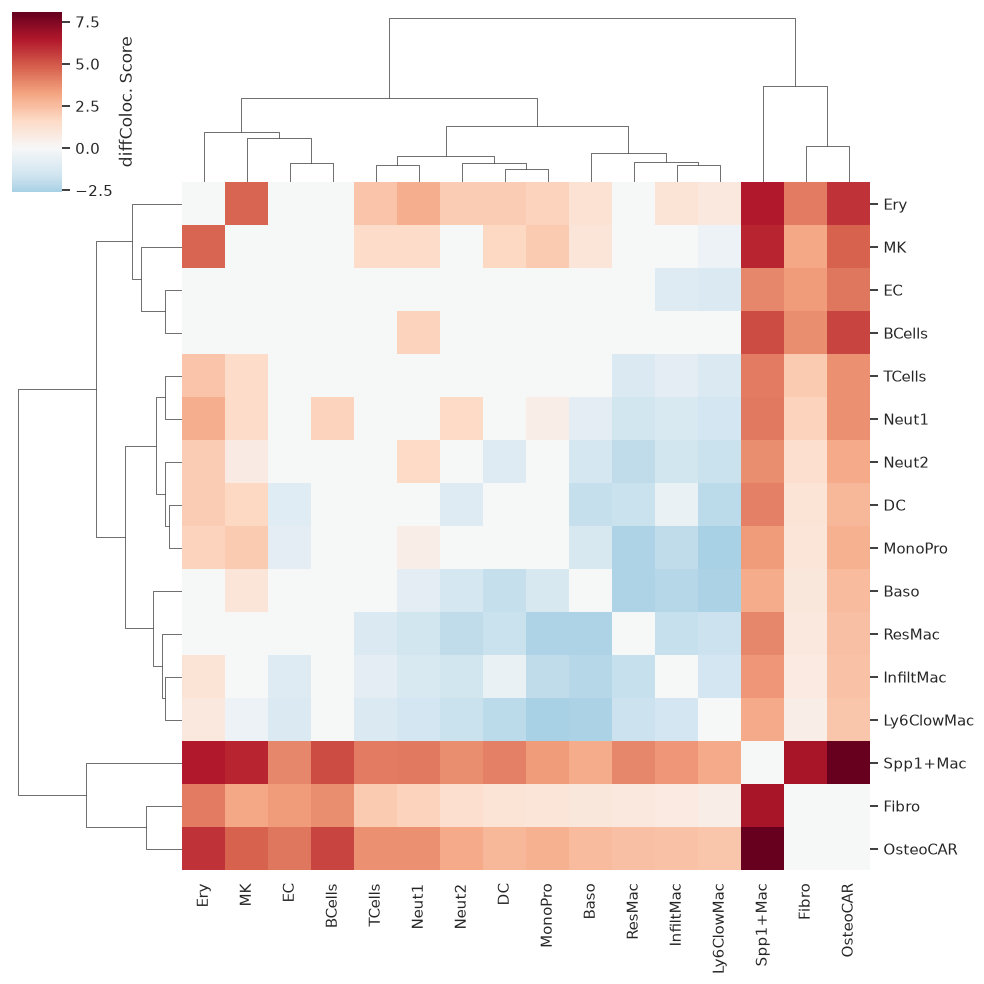

In [39]:
OvsE_TPO_HMdf,stats=nichesphere.coloc.OvsE_coloc_test_adjPval(observedColocProbs=colocPerSample.loc['TPO'], expectedColocProbs=scCTpairsProbs_TPO['count'], cell_types=CTprops.columns, 
                              testDistribution_df=df_100, oneCTinteractions=oneCTints, p=0.1)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

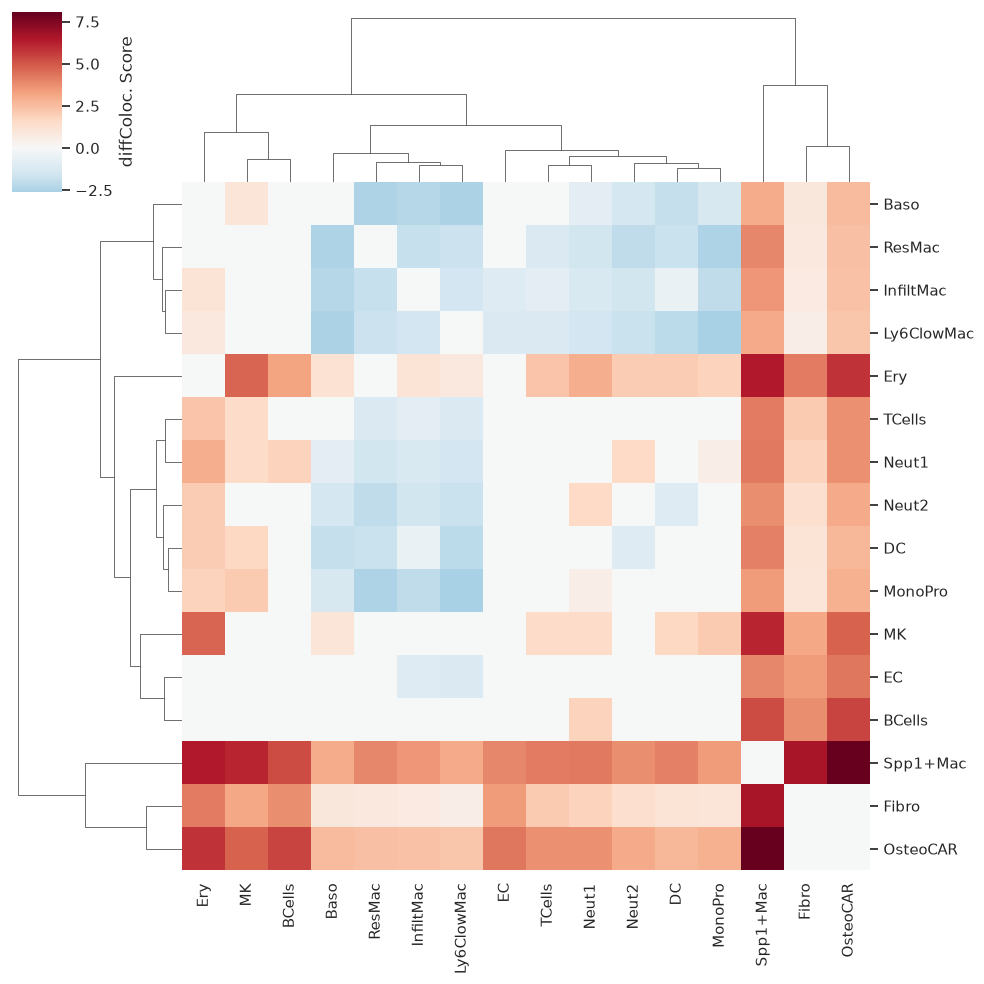

In [40]:
OvsE_TPO_HMdf,stats=nichesphere.coloc.OvsE_coloc_test_adjPval(observedColocProbs=colocPerSample.loc['TPO'], expectedColocProbs=scCTpairsProbs_TPO['count'], cell_types=CTprops.columns, 
                              testDistribution_df=df_500, oneCTinteractions=oneCTints, p=0.1)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

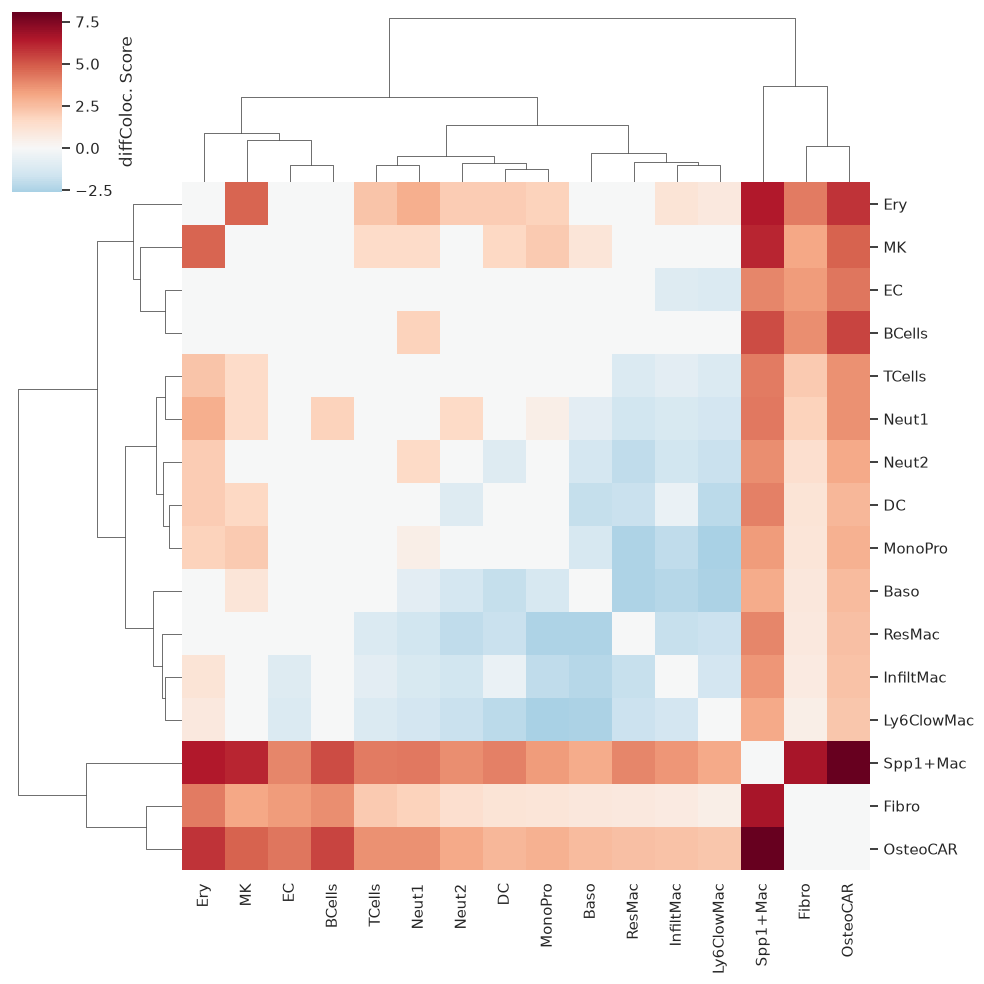

In [41]:
OvsE_TPO_HMdf,stats=nichesphere.coloc.OvsE_coloc_test_adjPval(observedColocProbs=colocPerSample.loc['TPO'], expectedColocProbs=scCTpairsProbs_TPO['count'], cell_types=CTprops.columns, 
                              testDistribution_df=df, oneCTinteractions=oneCTints, p=0.1)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

The OvsE_coloc_test function returns the statistics data as well:

In [42]:
stats.head()

,statistic,pvalue,adjusted_pvalue
DC-DC,0.000000,0.000,0.000000
DC-InfiltMac,-0.537164,0.000,0.000000
DC-Fibro,1.088154,0.000,0.000000
DC-MonoPro,0.000000,0.258,0.313024
DC-Neut2,-1.028178,0.002,0.003200


**Differential co-localization network**

To build the differential co-localization network, we will get an adjacency matrix (adj) based on the euclidean distances among the distributions of significant differential co-localization scores for the different cell types

In [43]:
HMdist=pd.DataFrame(scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(OvsE_TPO_HMdf)), 
                    columns=OvsE_TPO_HMdf.columns, index=OvsE_TPO_HMdf.index)

HMsimm=1-HMdist/HMdist.max().max()
##Cell pairs with not significant differential co-localization get 0
HMsimm[OvsE_TPO_HMdf==0]=0

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


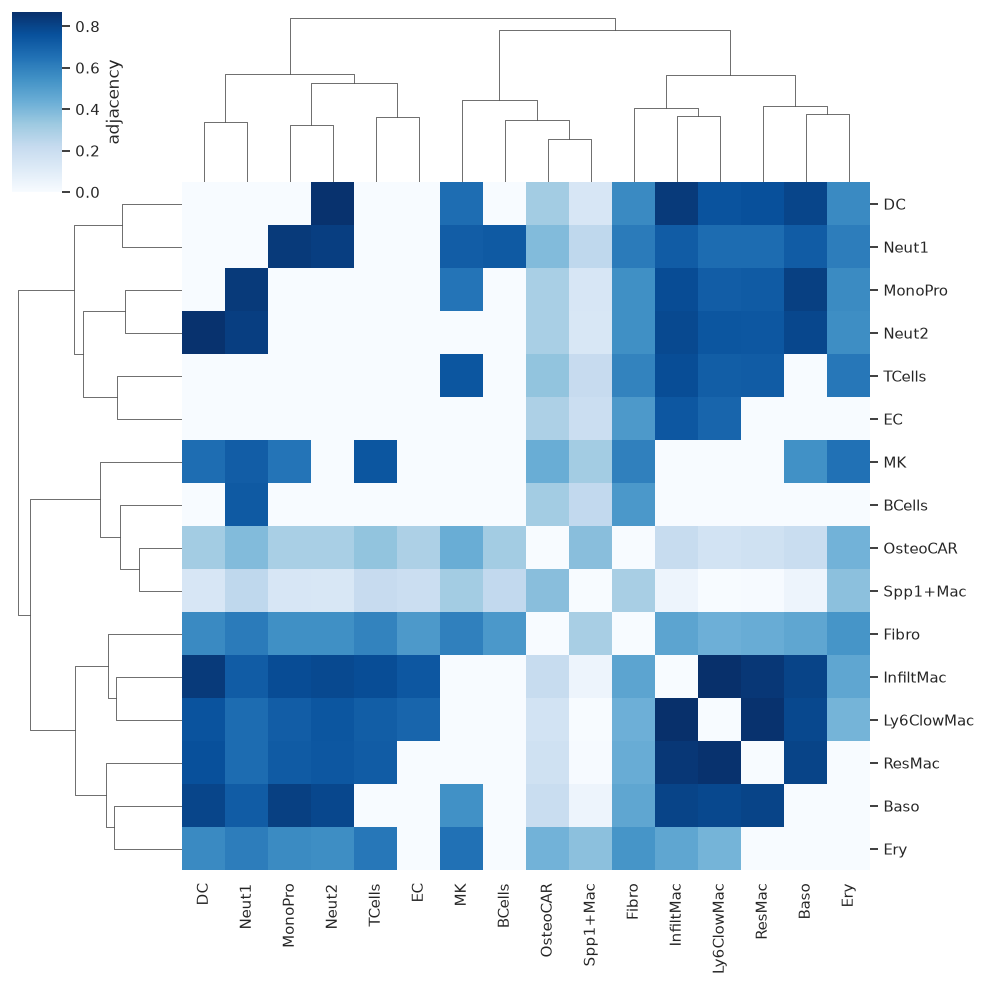

In [44]:
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})

We will assign each niche a color to plot them later on (we haven't clustered yet, so we use the same color for all nodes)

In [45]:
niches_dict={'1_': list(OvsE_TPO_HMdf.index)}
clist=['#4daf4a']

Then the network is built just taking into account the differentially co-localized cell type pairs. The cell groups dictionary can be used here to visualize different cell groups in different colors.

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/sit

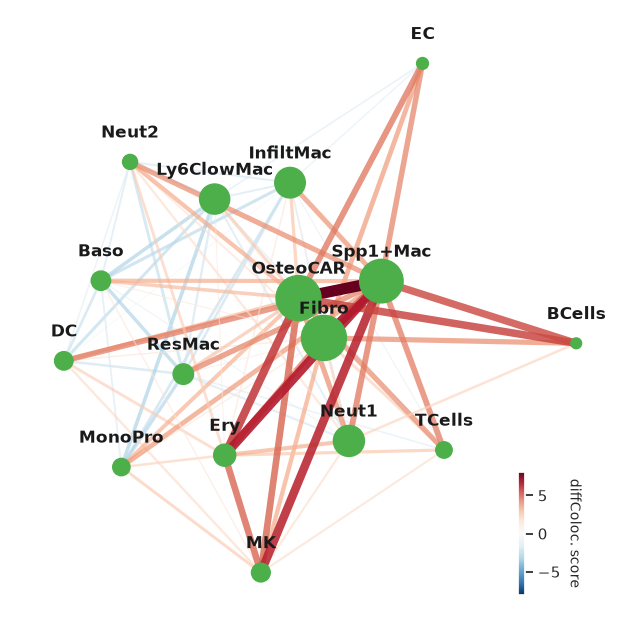

In [46]:
plt.rcParams['axes.facecolor'] = "None"
gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, adj=HMsimm,cell_group=niches_dict, clist=clist, nodeSize='betweeness', layout='neato', thr=0)

In [47]:
## Unsigned network
gCol2=nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

Now we'll do community detection using Louvain and make a communities dict

In [48]:
## Network clustering / clustering alternative
d=nx.algorithms.community.louvain_communities(gCol2,resolution=1.2, seed=1, weight='weight')
niches_dict=dict(enumerate([list(x) for x in d]))
niches_dict

{0: ['Baso', 'ResMac', 'Neut2', 'DC'],
 1: ['Spp1+Mac', 'MK', 'Ery', 'TCells', 'OsteoCAR'],
 2: ['InfiltMac', 'EC', 'Ly6ClowMac'],
 3: ['BCells', 'Fibro', 'Neut1', 'MonoPro']}

In [49]:
niche_names=['1_Resident_myeloid_niche', '2_FibCore', '3_Macrophage_vascular_niche', '4_Fibro_myeloid_niche']
niches_dict=dict(zip(niche_names,list(niches_dict.values()))) 


In [50]:
#Niches colors
clist=['#FF8C00', '#32CD32',  '#E64B35', '#FFD700']

niche_cols=pd.Series(clist, index=list(niches_dict.keys()))
niches_df=nichesphere.tl.cells_niche_colors(CTs=CTprops.columns, niche_colors=niche_cols, niche_dict=niches_dict)

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/tl.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  niche_df['color']=niche_colors[0]


We will use the community-layout library function **CommunityLayout** to show the communities in a layout suited for this. This function is compatible with networkx (Hagberg et. al., 2008) community detection functions, which will be used internally as indicated by the parameters **community_algorithm** and **community_kwargs**

In [51]:
## Calculate community layout
cl=CommunityLayout(gCol2,
        community_compression = 0.4,
        layout_algorithm = nx.spring_layout,
        layout_kwargs = {"k":75, "iterations":1000},
        community_algorithm = nx.algorithms.community.louvain_communities,
        community_kwargs = {"resolution":1.2,  'seed':1, 'weight':'weight'})

Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 425.98it/s]


/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/coloc.py:697: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(gCol,pos=pos,edge_color=inter[edgeCols=='lightblue'],
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/sit

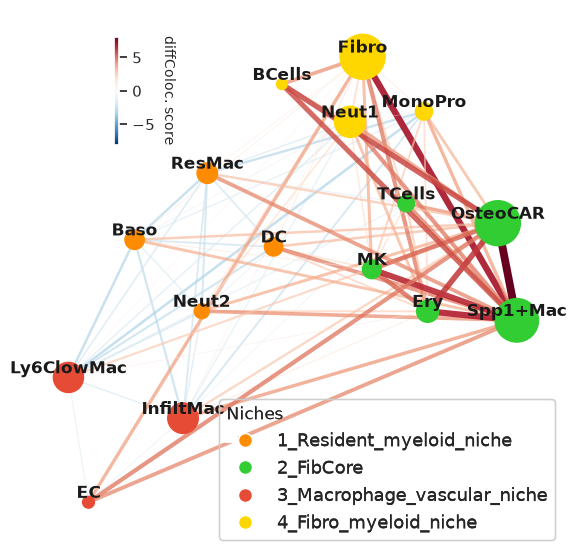

In [52]:
#pos=cl.full_positions
# Load positions
pos = np.load('../res_data/revision/node_positions/diffColocNW_node_pos.npy',allow_pickle='TRUE').item()

gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, 
                               adj=HMsimm,
                               cell_group=niches_dict, 
                               clist=clist, 
                               nodeSize='betweeness', 
                               layout=None,                         #layout needs to be set to None if we provide node positions
                               lab_spacing=0.05, 
                               thr=0,  
                               pos=pos,                             #node positions (from the CommunityLayout function)
                               edge_scale=0.7,                        #edge width
                               legend_ax=[0.05, 0.75, 0.15, 0.2],
                               fsize=(7,7)
                              )    #legend position
#Legend
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, 
                             label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]
plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='lower right', fontsize=13, title='Niches', 
                                alignment='left'))

plt.savefig('../figures/revision/F2/F2B.pdf')


In [53]:
np.save('../res_data/revision/node_positions/diffColocNW_node_pos.npy', pos) 

We can then calculate some network statistics with the networkX package [ref] functions:

In [54]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()

,betweenness,pagerank,degree_positive,degree_negative
DC,22.697681,-1.020317,0.333333,0.333333
InfiltMac,-6.489179,-2.196781,0.266667,0.600000
Fibro,30.776810,2.731931,0.933333,0.000000
MonoPro,22.697681,-1.134020,0.400000,0.266667
Neut2,22.697681,-1.056960,0.333333,0.333333


And visualize them

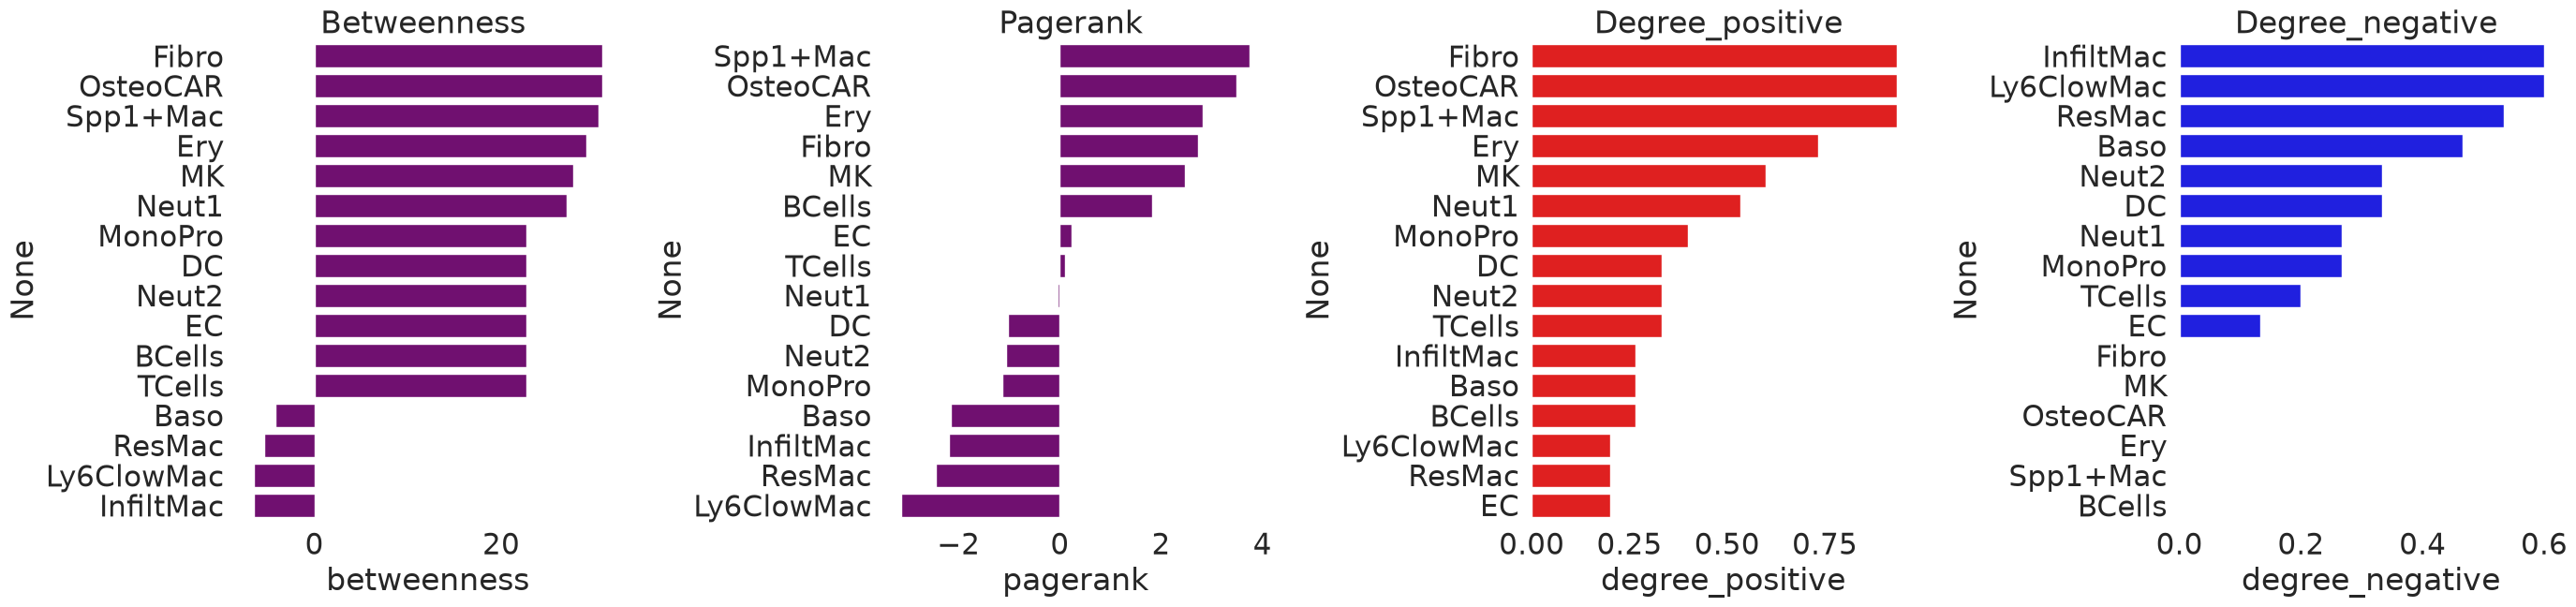

In [55]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats)
plt.savefig('../figures/revision/FS2/FS2B.pdf', bbox_inches='tight')

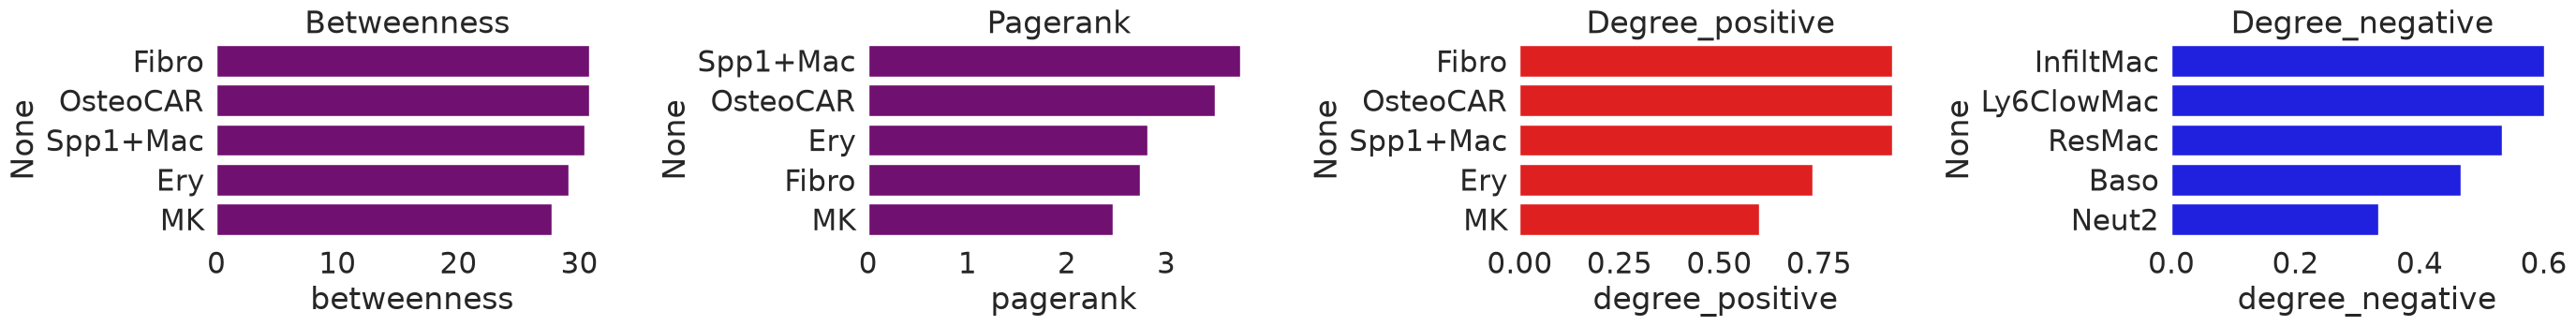

In [56]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats, top_n=5)

In [57]:
################ Edges within and between niches

In [58]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = "None"

In [59]:
vc_map={node: i for i, members in enumerate(d) for node in members}

In [60]:
# your fixed mapping from community id to name
community_names = {
    0: "1_Neut_ResMac_Baso_DC",
    1: "2_FibCore",
    2: "3_Macs_EC",
    3: "4_BCells_Fibro"
    # ... etc, one entry per community id currently in vc_map
}

vc_map_named = {node: community_names[comm_id] for node, comm_id in vc_map.items()}

In [61]:
sns.set(font_scale=0.8)
plt.rcParams['axes.facecolor'] = "None"

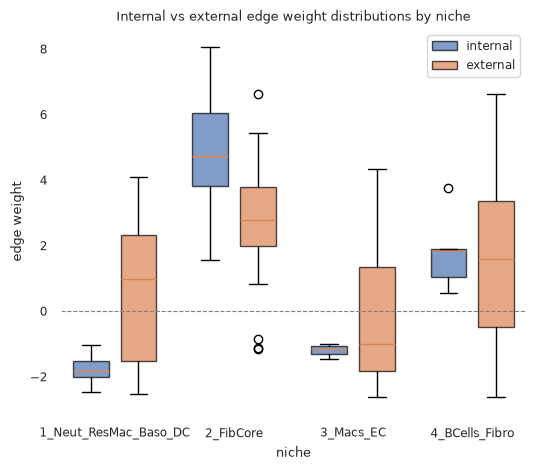

In [62]:
nichesphere.niche_stats.plot_internal_external_boxplots(gCol, vc_map_named)
plt.savefig('../figures/revision/FS2/FS2A.pdf', dpi=900)

In [63]:
signed=nichesphere.niche_stats.community_signed_weight_distributions(gCol, vc_map_named)
communities = sorted(signed.keys())

internal_data = [signed[c]["internal"] for c in communities]
external_data = [signed[c]["external"] for c in communities]

In [64]:
nichesphere.niche_stats.pairwise_ranksums_int_ext(internal_data, external_data, communities)

,niche,statistic,p_value,p_value_corrected
0,1_Neut_ResMac_Baso_DC,-2.334620,0.019563,0.039127
1,2_FibCore,2.743012,0.006088,0.024351
2,3_Macs_EC,-0.308607,0.757621,0.850436
3,4_BCells_Fibro,0.188562,0.850436,0.850436


## **Process based localized differential communication**

One of the advantages of NicheSphere is that it allows process based localized differential communication testing by looking at changes in LR interactions involved in specific processes between niches. To do this, we will first run pyCrossTalker to get the LR interactions data per condition.

In [65]:
########## New: PyCTKR

In [66]:
obs=pd.read_csv('../data/PICseq/intermediate_steps/rds/singlets_raw/singlets_raw_meta.csv', index_col=0)
counts=scipy.io.mmread('../data/PICseq/intermediate_steps/rds/singlets_raw/singlets_raw.mtx')
mk_names=pd.read_csv('../data/PICseq/intermediate_steps/rds/singlets_raw/singlets_raw_genes.csv', index_col=0)

/tmp/ipykernel_1787107/1171836211.py:2: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  counts=scipy.io.mmread('../data/PICseq/intermediate_steps/rds/singlets_raw/singlets_raw.mtx')


In [67]:
import anndata as ad
adata_singlets_raw=ad.AnnData(pd.DataFrame(counts.T.todense(), columns=mk_names.x))
adata_singlets_raw.obs_names=obs.index

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [68]:
adata_singlets_raw=adata_singlets_raw[adata_singlets.obs_names]
adata_singlets_raw.obs=adata_singlets.obs

In [69]:
import os

In [70]:
from pycrosstalker import tools as cttl
from pycrosstalker import plots as ctpl
import liana as li

In [71]:
adata_singlets_raw.raw = adata_singlets_raw

adata_singlets_raw.uns['liana'] = {}
for i in set(adata_singlets_raw.obs['stage']):
    #if i != 'fibrotic':
    lr=li.method.cellphonedb(adata_singlets_raw[adata_singlets_raw.obs['stage']==i],
                        groupby='annotation',
                        expr_prop=0.1,
                        verbose=True,
                        resource_name='mouseconsensus',
                        inplace=False)
    adata_singlets_raw.uns['liana'][i] = lr

Using resource `mouseconsensus`.
Using `.raw`!
Converting to sparse csr matrix!
1104 features of mat are empty, they will be removed.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.28 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14673 samples and 1084 features


100%|██████████| 1000/1000 [00:48<00:00, 20.77it/s]
Using resource `mouseconsensus`.
Using `.raw`!
Converting to sparse csr matrix!
1129 features of mat are empty, they will be removed.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.30 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 12373 samples and 1070 features


100%|██████████| 1000/1000 [00:52<00:00, 19.09it/s]


In [72]:
adata_singlets_raw = cttl.utils.from_liana(adata_singlets_raw)
adata_singlets_raw.uns['pycrosstalker']['details'] = {}
adata_singlets_raw.uns['pycrosstalker']['details']['filename'] = "PICseq"

In [73]:
output = "../res_data/revision/output_ctkr/PICseq/"
if not os.path.isdir(output):
    os.mkdir(output)
adata_singlets_raw = cttl.analise_LR(adata_singlets_raw, out_path=output,comparison=[("TPO","EV")])

Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done
Generating h5ad file with Analysed Results


Then we will assign each cell type pair its corresponding niche pair:

In [74]:
oneCTints=pd.Series(oneCTints)

In [75]:
pairCatDFdir=nichesphere.tl.get_pairCatDFdir(niches_df)
pairCatDFdir.head()

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/tl.py:514: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/tl.py:515: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


,cell_pairs,niche_pairs
0,DC->DC,1_Resident_myeloid_niche->1_Resident_myeloid_n...
1,DC->InfiltMac,1_Resident_myeloid_niche->3_Macrophage_vascula...
2,DC->Fibro,1_Resident_myeloid_niche->4_Fibro_myeloid_niche
3,DC->MonoPro,1_Resident_myeloid_niche->4_Fibro_myeloid_niche
4,DC->Neut2,1_Resident_myeloid_niche->1_Resident_myeloid_n...


We will also filter cell type pairs with non significant differential co-localization scores. Cell pairs with filter=1 will be tested

In [76]:
## To filter communication data (network)
colocFilt=nichesphere.tl.getColocFilter(pairCatDF=pairCatDFdir, adj=HMsimm, oneCTints=oneCTints.str.replace('-', '->'))
#colocFilt.to_csv('../res_data/revision/colocFilt_PIC_updt.csv')
colocFilt.head()

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/tl.py:575: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8330623548490335' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


,filter
cell_pairs,
DC->DC,1.0
DC->InfiltMac,1.0
DC->Fibro,1.0
DC->MonoPro,0.0
DC->Neut2,1.0


Get cell communication data (CrossTalkeR tables)

In [77]:
crossTalker_ctrlComm=adata_singlets_raw.uns['pycrosstalker']['path']['EV']
crossTalker_tpoComm=adata_singlets_raw.uns['pycrosstalker']['path']['TPO']

NicheSphere is suited to work with CrossTalkeR output tables which contain columns called **cellpair**, indicating the cell types involved in an interaction separated by '@'; and **allpair**, indicating cell types, ligand and receptor involved. Additionally, input tables for NicheSphere should contain columns indicating the **ligand** (gene_A), **receptor** (gene_B) and **communication score** (MeanLR). The names for these last 3 columns can be indicated in NicheSphere functions.

CrossTalkeR tables contain strings indicating wether a gene is a ligand (|L), receptor (|R) or transcription factor (|TF). These strings will be removed as they might cause conflicts with code. 

In [78]:
crossTalker_ctrlComm=nichesphere.tl.processCTKRoutput(crossTalker_ctrlComm)
crossTalker_tpoComm=nichesphere.tl.processCTKRoutput(crossTalker_tpoComm)

Next we will load the ligands database. This comes from tables from different databases 
which were concatenated. These tables indicate the processes in which different ligands are involved.

In [79]:
allDBs=pd.read_csv('../csv/nichesphereDB_pmid.csv', index_col=0)
allDBs['Ligand']=allDBs['Ligand'].str.lower()
allDBs.head()

,Ligand,category,db,PMID
2,col1a1,Collagens,matrisome,36399478
3,col1a2,Collagens,matrisome,36399478
4,col1a1,Collagens,matrisome,36399478
5,col6a3,Collagens,matrisome,36399478
6,col1a2,Collagens,matrisome,36399478


In [80]:
allDBs_sub=allDBs[allDBs.category!='apoptosis']
allDBs_sub=allDBs_sub[allDBs_sub.category!='phagocytosis']
allDBs_sub=allDBs_sub.drop_duplicates()

In [81]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = "None"

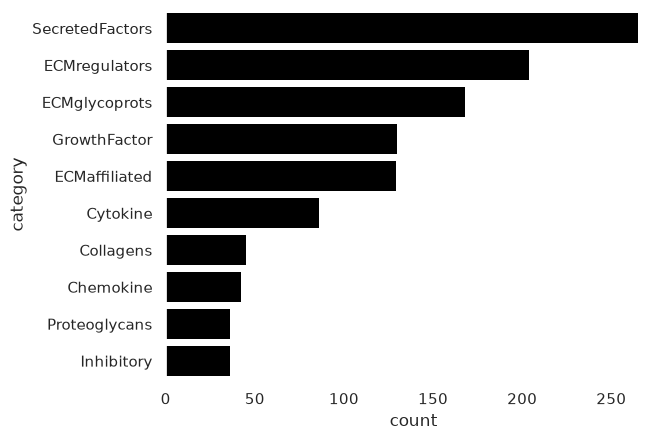

In [82]:
sns.set_context(rc = {'patch.linewidth': 0.0})
ax = sns.barplot(x=allDBs_sub.category.value_counts(), y=allDBs_sub.category.value_counts().index,
            data=pd.DataFrame(allDBs_sub.category.value_counts()), color='black')
sns.despine()

Then we'll separate communication scores by process to know which cell type pairs and niche pairs are interacting through which processes in each condition.

In [83]:
EV_CTpairScores_byCat2_dir_colocClusts=nichesphere.comm.lr_ctPairScores_perCat_dir(ccommTable=crossTalker_ctrlComm, db=allDBs_sub, dbCatCol='category', dbMatchCol='Ligand', 
                        ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR', oneCTinteractions=oneCTints.str.replace('-', '@'), condition='EV', pairCatDF=pairCatDFdir)

In [84]:
tpoCTpairScores_byCat2_dir_colocClusts=nichesphere.comm.lr_ctPairScores_perCat_dir(ccommTable=crossTalker_tpoComm, db=allDBs_sub, dbCatCol='category', dbMatchCol='Ligand', 
                        ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR', oneCTinteractions=oneCTints.str.replace('-', '@'), condition='TPO', pairCatDF=pairCatDFdir)

Some interactions might be present only in one condition, so we will assign 0 values to the interactions that do not appear in one condition to be able to compare conditions

In [85]:
EV_CTpairScores_byCat2_dir_colocClusts, tpoCTpairScores_byCat2_dir_colocClusts = nichesphere.comm.equalizeScoresTables(ctrlTbl=EV_CTpairScores_byCat2_dir_colocClusts, 
                                                    expTbl=tpoCTpairScores_byCat2_dir_colocClusts, ctrlCondition='EV', expCondition='TPO')

Filter by co-localization

In [86]:
EV_CTpairScores_byCat2_dir_colocClusts=EV_CTpairScores_byCat2_dir_colocClusts[[i in colocFilt.index[colocFilt['filter']==1] for i in EV_CTpairScores_byCat2_dir_colocClusts.cell_pairs]]
tpoCTpairScores_byCat2_dir_colocClusts=tpoCTpairScores_byCat2_dir_colocClusts[[i in colocFilt.index[colocFilt['filter']==1] for i in tpoCTpairScores_byCat2_dir_colocClusts.cell_pairs]]

In [87]:
## Count significant interactions per mechanism after coloc. filtering
tpoCTpairScores_byCat2_dir_colocClusts.LRcat.value_counts()

LRcat
SecretedFactors    2210
ECMregulators      1604
ECMglycoprots      1525
GrowthFactor       1338
Cytokine            994
Collagens           778
ECMaffiliated       691
Proteoglycans       309
Chemokine           286
Inhibitory          172
Name: count, dtype: int64

Then we can test for differential cell cell communication between niche pairs or cell pairs across processes with the function 'tl.diffCcommStats'. We will first test per niche pair setting the parameter 'cellCatCol' to 'niche_pairs', which is the column in the tables of communication scores by process containing niche pairs:

In [88]:
## Differential communication statistics
EVtpo_diffCcommTable_colocGroups_dir=nichesphere.comm.diffCcommStats(c1CTpairScores_byCat=tpoCTpairScores_byCat2_dir_colocClusts, c2CTpairScores_byCat=EV_CTpairScores_byCat2_dir_colocClusts, cellCatCol='niche_pairs')


/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:175: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:177: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:175: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:177: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.


In [89]:
EVtpo_diffCcommTable_colocGroups_dir_filt=EVtpo_diffCcommTable_colocGroups_dir.copy()

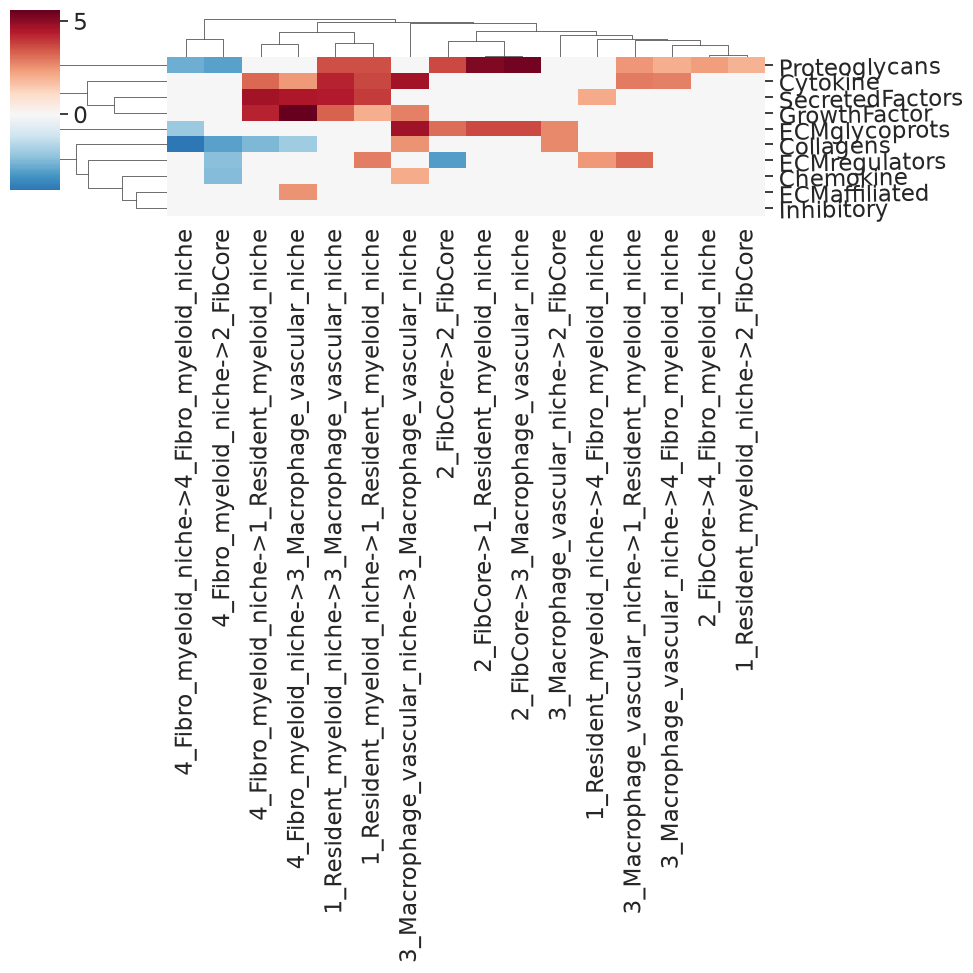

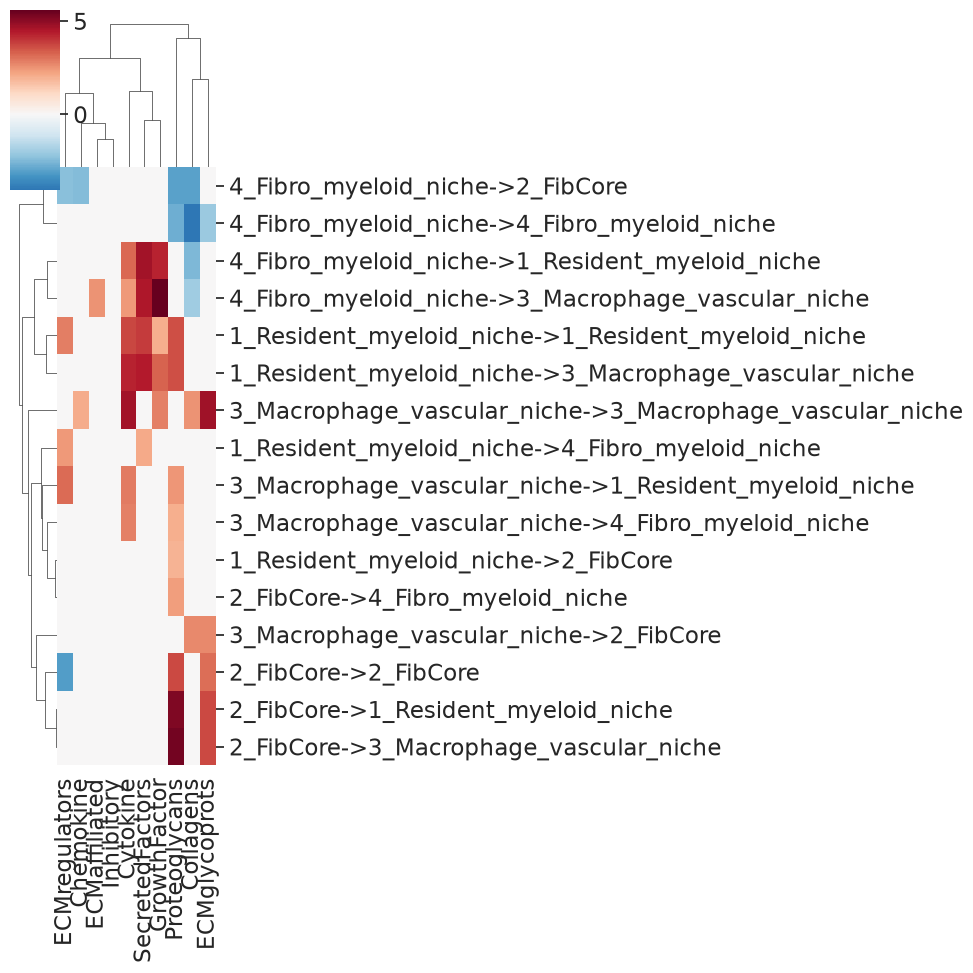

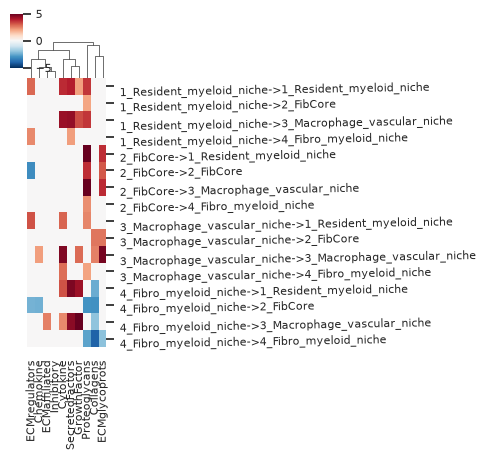

In [90]:
## Differential communication by coloc group

## Plot in heatmap
hm_df, cm=nichesphere.comm.plotDiffCcommStatsHM(diffCommTable=EVtpo_diffCcommTable_colocGroups_dir_filt, min_pval=0.05)
hm_df=hm_df.T[hm_df.sum()!=0].T

sns.clustermap(hm_df.T.sort_index(), cmap='RdBu_r', center=0, method='complete')

cm=sns.clustermap(hm_df.T.sort_index(), cmap='RdBu_r', center=0, method='complete', row_cluster=False, vmin=-5, vmax=5)

plt.setp(cm.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)

hm = cm.ax_heatmap.get_position()
plt.setp(cm.ax_heatmap.yaxis.get_majorticklabels(), fontsize=8)
plt.setp(cm.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)

## heatmap position
cm.ax_heatmap.set_position([hm.x0, hm.y0, hm.width*0.5, hm.height*0.45])
col = cm.ax_col_dendrogram.get_position()
## dendrograms position
cm.ax_col_dendrogram.set_position([col.x0, col.y0*0.6, col.width*0.5, col.height*0.25])
row = cm.ax_row_dendrogram.get_position()
cm.ax_row_dendrogram.set_position([row.x0*3.5, row.y0, row.width*0.2, row.height*0.45])
## colorbar position
x0, y0, w, h = cm.cbar_pos
cm.ax_cbar.set_position([x0*2.5, y0*0.63, w*0.25, h*0.3])
cm.tick_params(labelsize=8)

plt.savefig('../figures/revision/F2/F2D.pdf')
plt.show()

Localized differential communication networks

To build process specific differential cell communication networks, we will look at differential cell communication per cell type pair per process, so we will do the differential communication test again, this time setting 'cellCatCol' to 'cell_pairs', which is the column in the tables of communication scores by process containing cell pairs

In [91]:
## Differential cell communication per cell type pair

## Differential communication statistics
EVtpo_diffCcommTable2_CTpair_dir=nichesphere.comm.diffCcommStats(c1CTpairScores_byCat=tpoCTpairScores_byCat2_dir_colocClusts, c2CTpairScores_byCat=EV_CTpairScores_byCat2_dir_colocClusts, cellCatCol='cell_pairs')


/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:175: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:177: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:175: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/nichesphere/comm.py:177: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
/data/hu367653/.cond

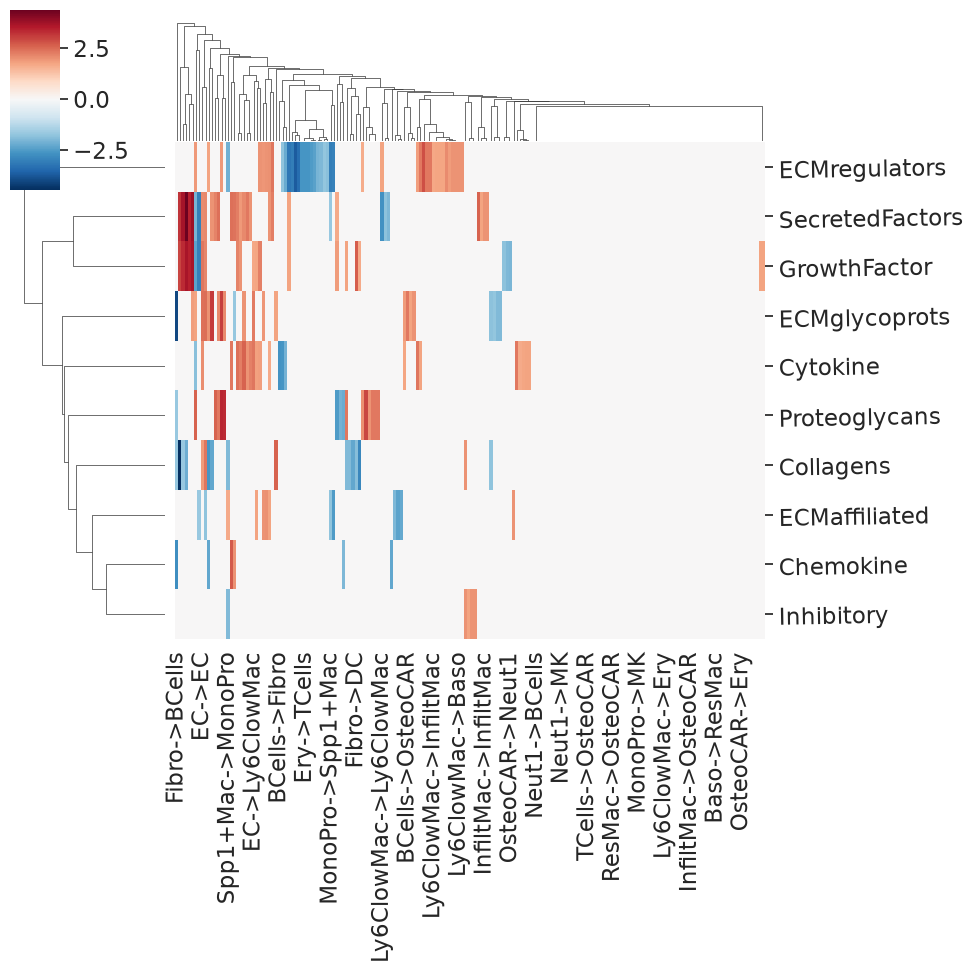

In [92]:
x_EVtpo_dir, plothm=nichesphere.comm.plotDiffCcommStatsHM(diffCommTable=EVtpo_diffCcommTable2_CTpair_dir, min_pval=0.1)

Now we can plot differential cell communication scores per process on the co-localization network

In [93]:
sns.set(font_scale=1)

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1695: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


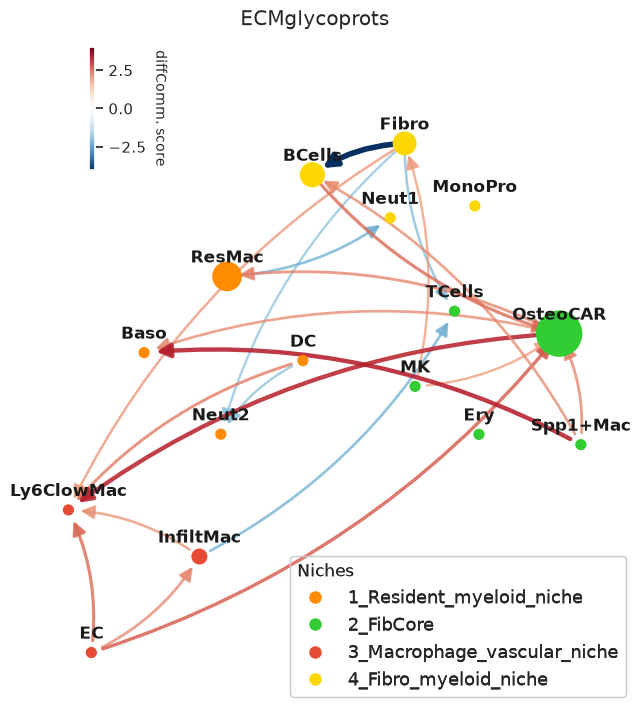

In [94]:
x_chem=nichesphere.comm.getDiffComm(diffCommTbl=x_EVtpo_dir, pairCatDF=pairCatDFdir, ncells=16, cat='ECMglycoprots')

plt.rcParams['axes.facecolor'] = "None"
plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)

G=nichesphere.comm.catNW(x_chem=x_chem,colocNW=gCol, cell_group=niches_dict, group_cmap='tab20', ncols=20, plot_title='ECMglycoprots', clist=clist, nodeSize='betweeness',
       legend_ax=[0.0, 0.87, 0.15, 0.2], pos=pos, thr=0, layout=None, lab_spacing=0.05)
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]

plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='lower right', fontsize=13, title='Niches', alignment='left'))
plt.savefig('../figures/revision/F2/F2E.pdf')

In [95]:
t0=pd.DataFrame({'betweenness':[nx.betweenness_centrality(G)[x] for x in list(G.nodes)], 
             'degree':[nx.degree_centrality(G)[x] for x in list(G.nodes)], 'pagerank':[nx.pagerank(G, weight=None)[x] for x in list(G.nodes)]})
t0.index=list(G.nodes)

In [96]:
nw_stats_proc = nichesphere.tl.compute_network_stats(G)
nw_stats_proc.head()

,betweenness,pagerank,degree_positive,degree_negative
DC,0.000000,-0.382818,0.066667,0.066667
InfiltMac,0.000000,-0.061306,0.133333,0.066667
Fibro,24.505035,0.128143,0.133333,0.200000
MonoPro,0.000000,-0.382818,0.000000,0.000000
Neut2,0.000000,-1.413332,0.000000,0.133333


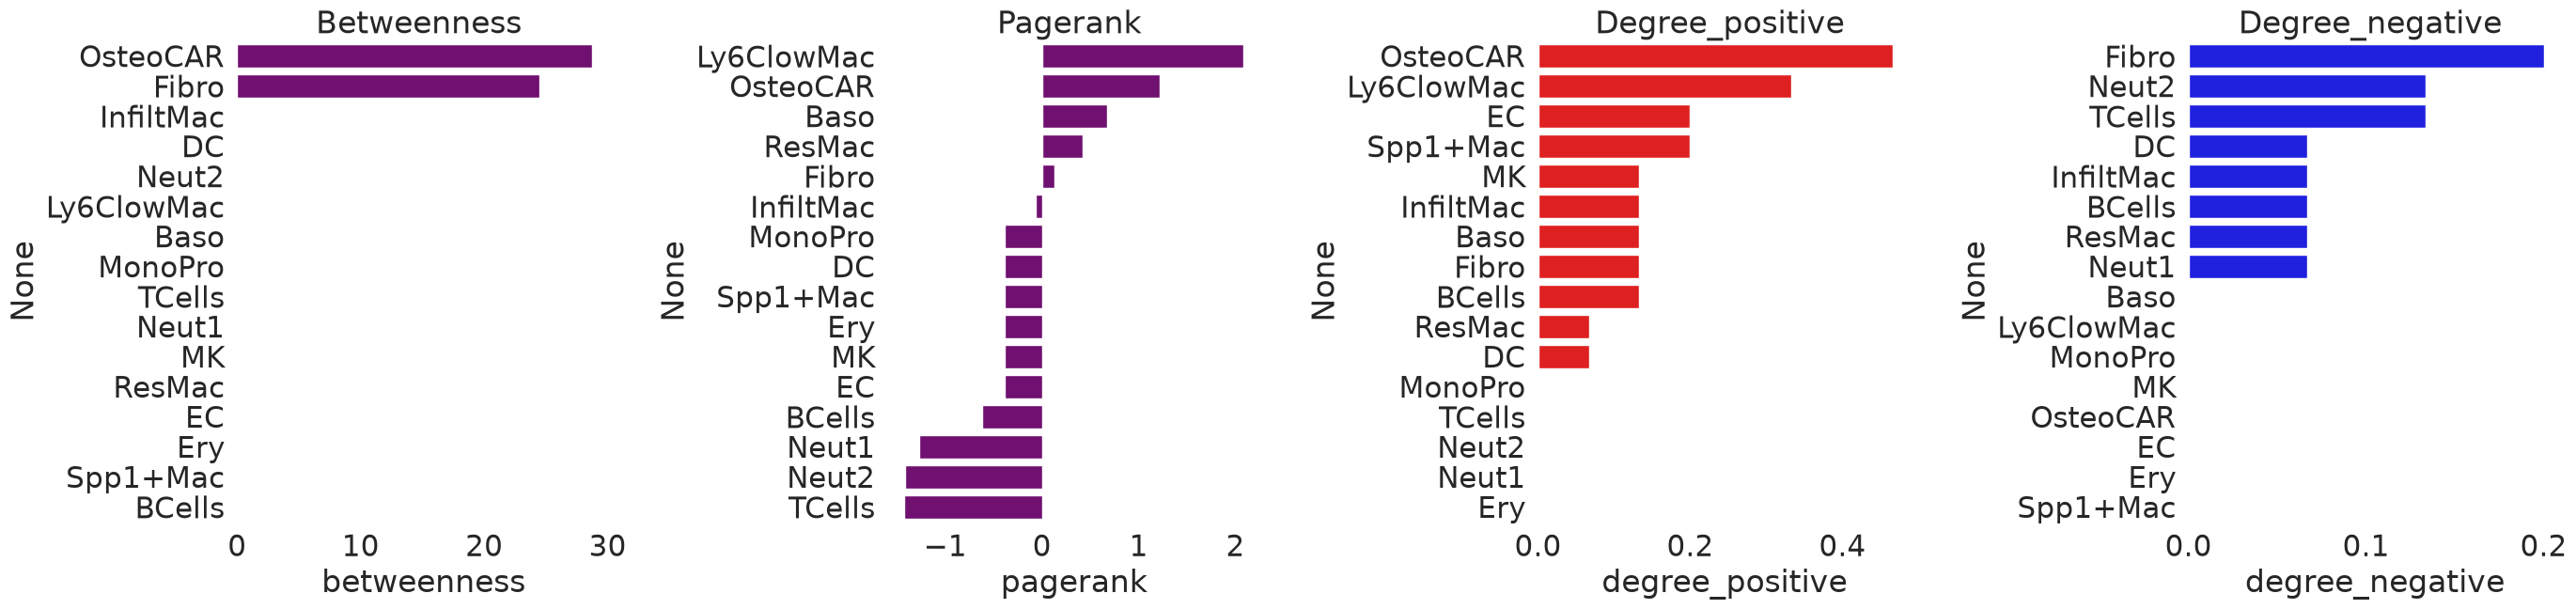

In [97]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats_proc)
plt.savefig('../figures/revision/FS2/FS2H.pdf', bbox_inches='tight')

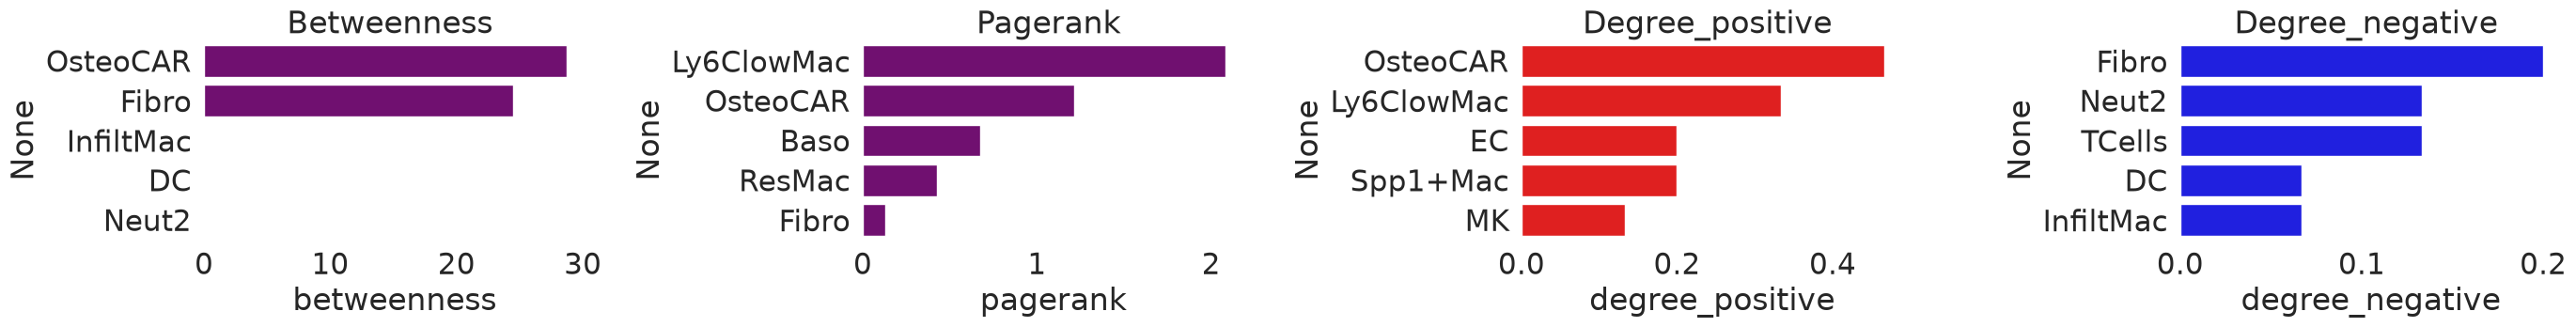

In [98]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats_proc, top_n=5)


In [99]:
##### Py CTKR

In [100]:
ECM_GPs=list(allDBs_sub.Ligand[allDBs_sub.category=='ECMglycoprots'])

In [101]:
fibCore=['Spp1+Mac', 'BCells', 'MK', 'TCells', 'EC', 'OsteoCAR', 'Ery']

In [102]:
## subset by coloc
data_sub=adata_singlets_raw.uns['pycrosstalker']['results']['tables']['TPO_x_EV'].loc[[j in list(colocFilt.index[[i==1 for i in colocFilt['filter']]]) for j in adata_singlets_raw.uns['pycrosstalker']['results']['tables']['TPO_x_EV'].source+'->'+adata_singlets_raw.uns['pycrosstalker']['results']['tables']['TPO_x_EV'].target]]

In [103]:
data_sub.head()

,allpair,ligpair,recpair,LRScore,type_gene_A,type_gene_B,gene_A,gene_B,source,target,cellpair,interaction_type
7,BCells/Adam10|L@Fibro/Axl|R,BCells/Adam10|L,Fibro/Axl|R,-0.042605,Ligand,Receptor,Adam10|L,Axl|R,BCells,Fibro,BCells@Fibro,LR
14,BCells/Adam10|L@OsteoCAR/Axl|R,BCells/Adam10|L,OsteoCAR/Axl|R,0.397408,Ligand,Receptor,Adam10|L,Axl|R,BCells,OsteoCAR,BCells@OsteoCAR,LR
15,BCells/Adam10|L@OsteoCAR/Notch2|R,BCells/Adam10|L,OsteoCAR/Notch2|R,-0.395993,Ligand,Receptor,Adam10|L,Notch2|R,BCells,OsteoCAR,BCells@OsteoCAR,LR
18,BCells/Adam10|L@Spp1+Mac/Axl|R,BCells/Adam10|L,Spp1+Mac/Axl|R,-0.523395,Ligand,Receptor,Adam10|L,Axl|R,BCells,Spp1+Mac,BCells@Spp1+Mac,LR
19,BCells/Adam10|L@Spp1+Mac/Cadm1|R,BCells/Adam10|L,Spp1+Mac/Cadm1|R,-0.467230,Ligand,Receptor,Adam10|L,Cadm1|R,BCells,Spp1+Mac,BCells@Spp1+Mac,LR


In [104]:
data_sub.to_csv('../res_data/revision/sankey/data_sub_coloc_sankey.csv')

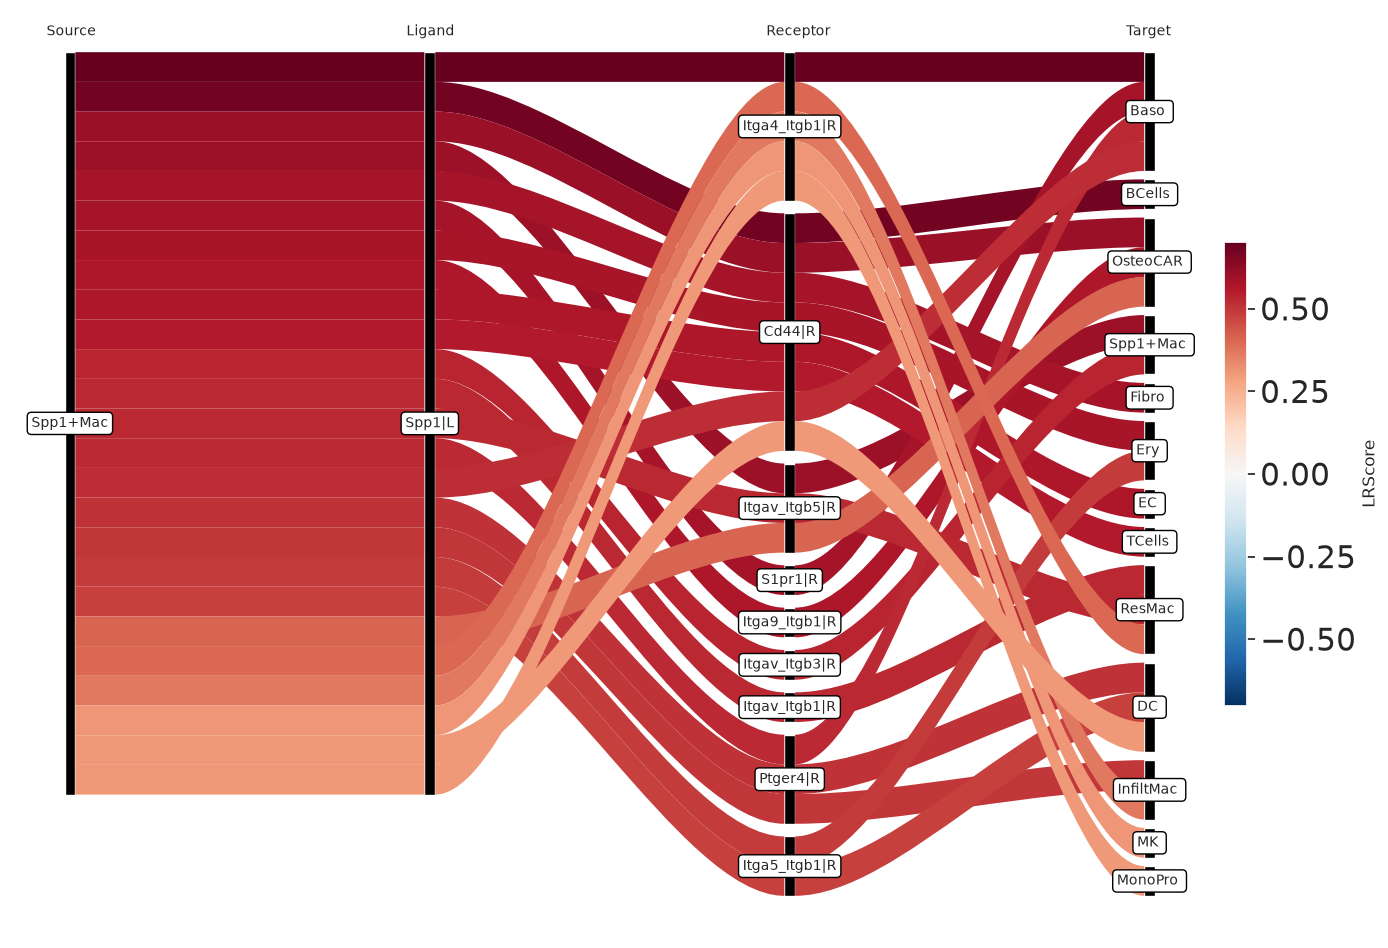

In [105]:
ctpl.plot_sankey(data_sub, ligand_cluster=['Spp1+Mac'], target='Spp1|L', threshold = 25, plt_name="")

In [106]:
# sankey_plot module plot_custom_sankey
# Supports source_cell, ligand_list, receptor_list, threshold, save_path, etc.

Plotting 25 distinct fluid flow paths.


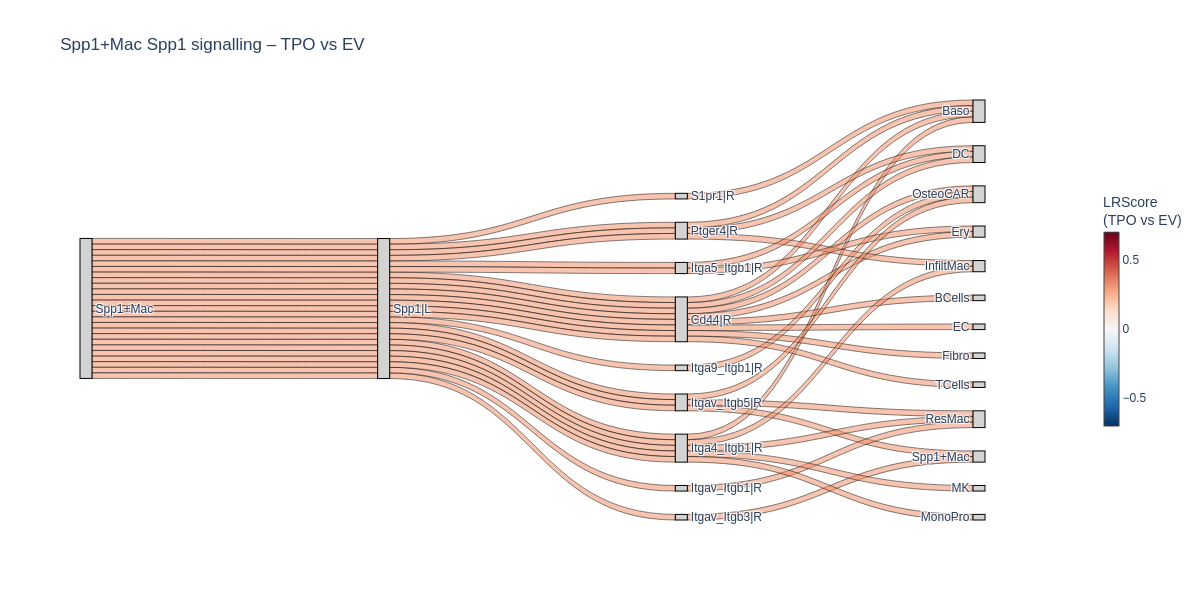

In [107]:
import module_01_sankey_plot as m01
fig = m01.plot_custom_sankey(
    adata_singlets_raw,
    table_key='TPO_x_EV',
    filter_df=colocFilt,
    source_cell='Spp1+Mac',
    ligand_gene='Spp1',
    threshold=25,
    title='Spp1+Mac Spp1 signalling – TPO vs EV',
    #save_path='../figures/revision/Spp1Mac_Spp1_sankey.html',
)
fig.show()

In [108]:
## subset by mechanism

In [109]:
data_sub=data_sub.loc[[i in ECM_GPs for i in data_sub['gene_A'].str.replace('|L', '').str.lower()]]

In [110]:
data_sub.to_csv('../res_data/revision/sankey/data_sub_coloc_glycoprots_sankey.csv')

Plotting 25 distinct fluid flow paths.


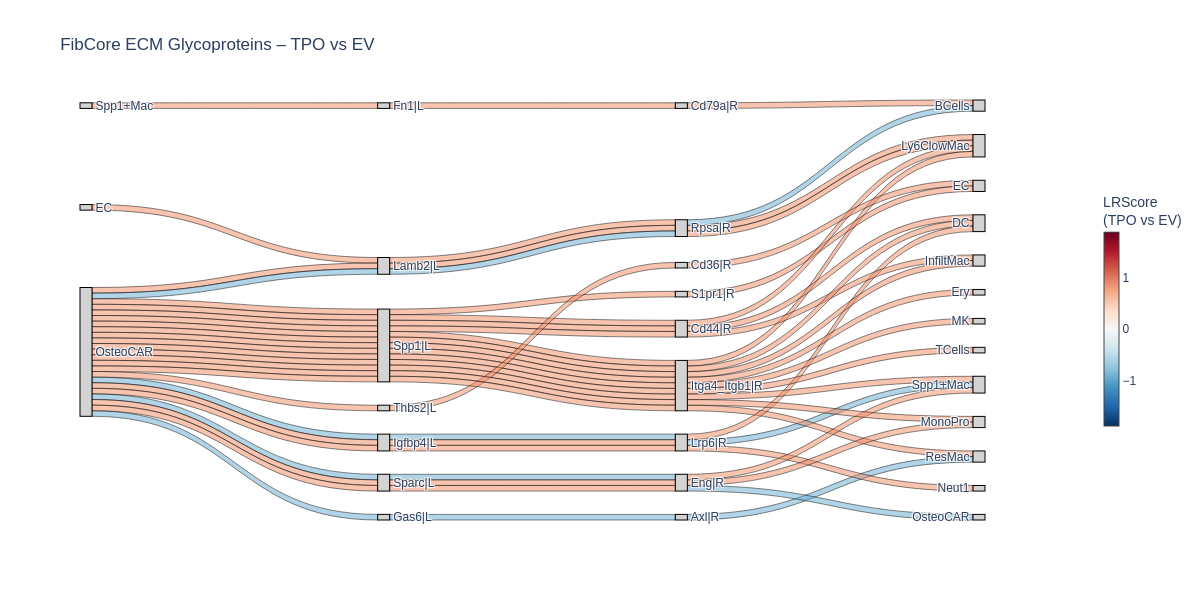

In [111]:
fig = m01.plot_custom_sankey(
    adata_singlets_raw,
    table_key='TPO_x_EV',
    filter_df=colocFilt,
    source_cell=fibCore,
    ligand_list=ECM_GPs,
    threshold=25,
    title='FibCore ECM Glycoproteins – TPO vs EV',
    #save_path='../figures/revision/FibCore_ECMglycoprots_sankey.html',
)
fig.show()

In [112]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = "None"

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1695: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


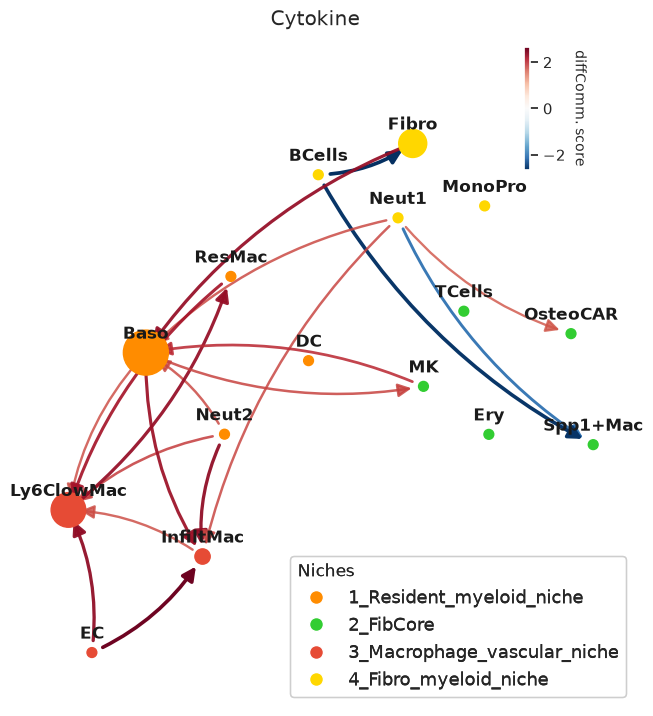

In [113]:
x_chem=nichesphere.comm.getDiffComm(diffCommTbl=x_EVtpo_dir, pairCatDF=pairCatDFdir, ncells=16, cat='Cytokine')

plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
G=nichesphere.comm.catNW(x_chem=x_chem,colocNW=gCol, cell_group=niches_dict, group_cmap='tab20', ncols=20, plot_title='Cytokine', clist=clist, nodeSize='betweeness',
       legend_ax=[0.7, 0.87, 0.15, 0.2], pos=pos, thr=0, layout=None, lab_spacing=0.05)
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]

plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='lower right', fontsize=13, title='Niches', alignment='left'))
plt.savefig('../figures/revision/F5/F5D.pdf')

In [114]:
nw_stats_proc = nichesphere.tl.compute_network_stats(G)
nw_stats_proc.head()

,betweenness,pagerank,degree_positive,degree_negative
DC,0.000000,-1.886930,0.000000,0.000000
InfiltMac,25.505035,-0.097094,0.333333,0.000000
Fibro,0.000000,-2.401826,0.066667,0.066667
MonoPro,0.000000,-1.886930,0.000000,0.000000
Neut2,0.000000,-1.886930,0.200000,0.000000


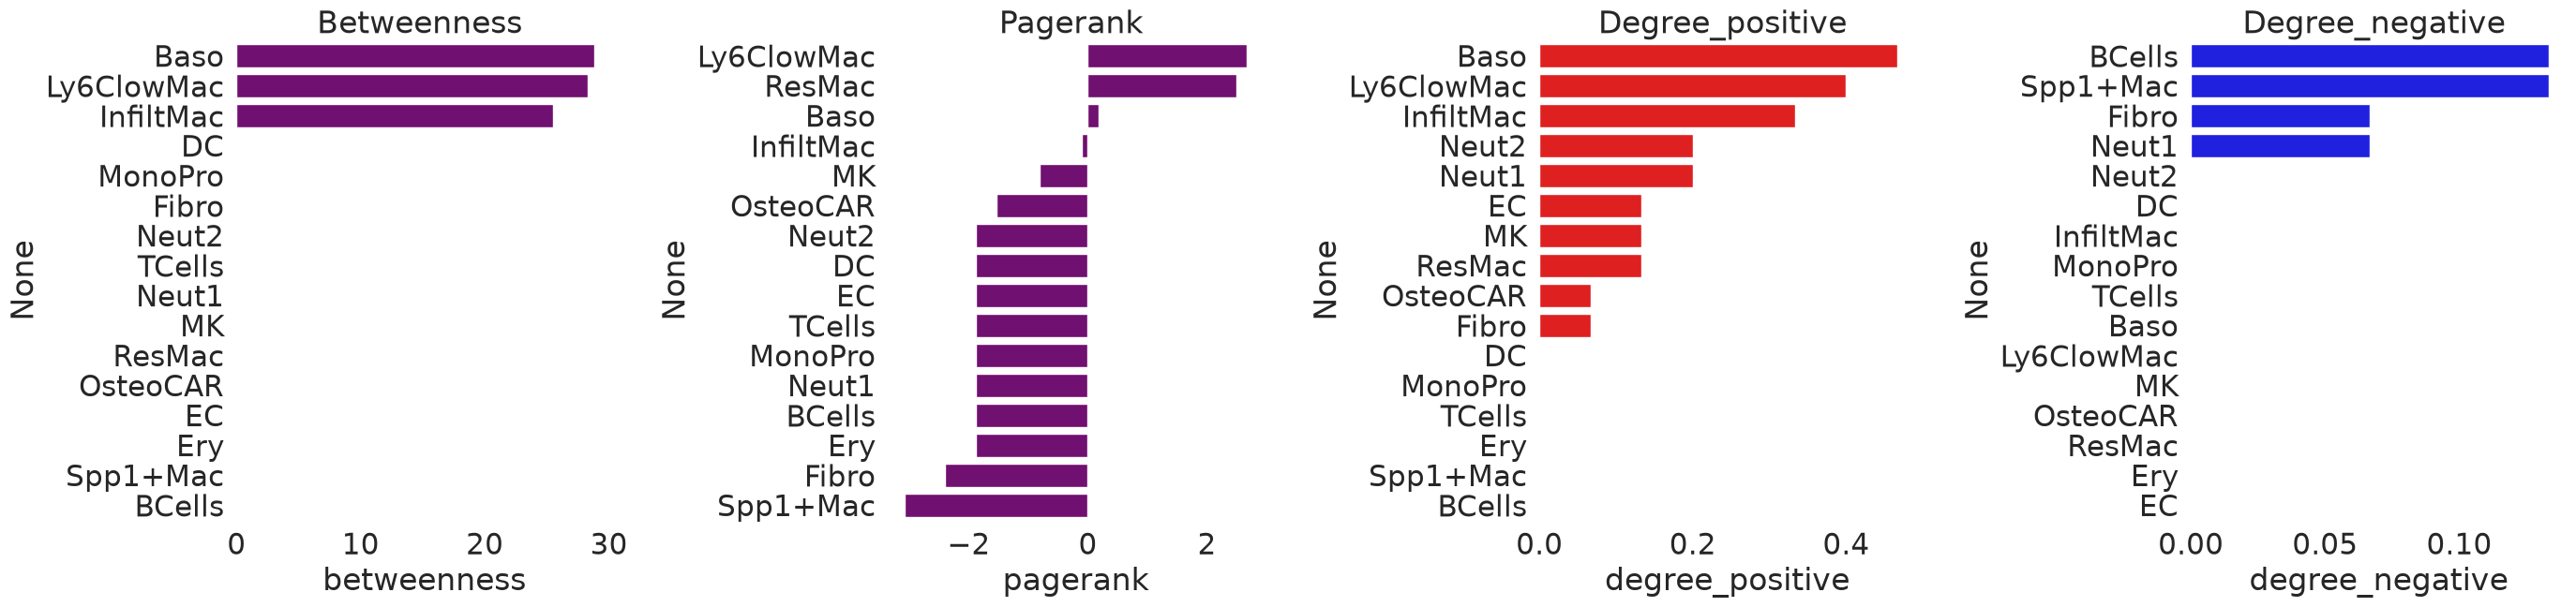

In [115]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats_proc)


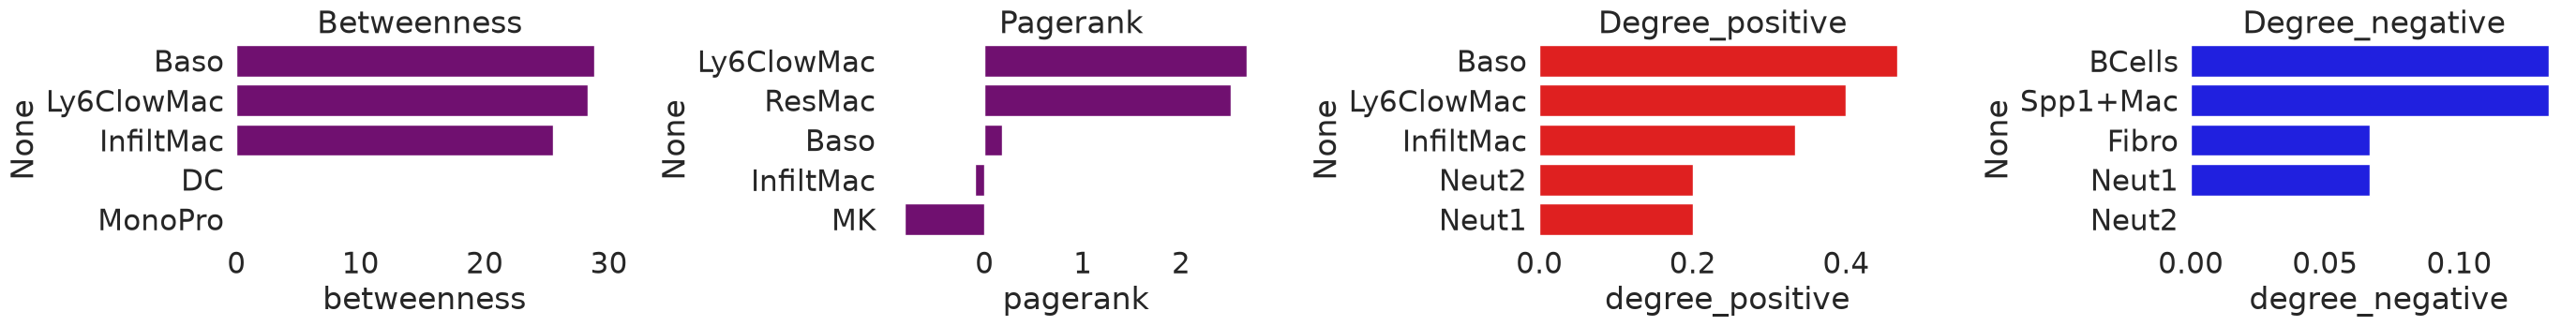

In [116]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats_proc, top_n=5)
